# EDA 통합 노트북

## 0. Setup

In [19]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic')
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# 모듈 경로 (FeatureEngineering, JNeighbors는 03_FeatureEngineering에 함께 있음)
FE_DIR = Path('../03_FeatureEngineering').resolve()
sys.path.insert(0, str(FE_DIR))

EDA_DIR = Path('./modules').resolve()
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

DATA_DIR = Path('../../data').resolve()
print(f'FE_DIR: {FE_DIR}')
print(f'DATA_DIR: {DATA_DIR}')

FE_DIR: D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\03_FeatureEngineering
DATA_DIR: D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\data


In [20]:
# EDA 모듈 임포트
import importlib
import eda_basic as basic
import eda_feature as feat
import eda_selection as sel
import eda_voice as voice
import eda_thumb as thumb
import eda_result as result
import FeatureEngineering as fe
from JNeighbors import make_jnn_features

# 모듈 수정 시 reload
for mod in [basic, feat, sel, voice, thumb, result]:
    importlib.reload(mod)

print('모듈 임포트 완료')

모듈 임포트 완료


## 1. 데이터 로드

In [21]:
# 원본 데이터 (필터링 완료 버전)
df = pd.read_csv(DATA_DIR / 'processed' / 'video_processed.csv', sep='\x01')
print(f'원본 데이터: {df.shape}')
df.head(1)

원본 데이터: (9110, 80)


,video_id,channel_id,title,description,published_at,channel_title,tags,category_id,default_language,default_audio_language,...,중립,긍정,intensity,sentiment,collaboration,new_category_id,viewer_interaction,error,like_per_sub,category_sub
0,iN7_1Xuaplo,UC-oCJP9t47v7-DmsnmXV38Q,술애기,*SOOP live stream\nhttps://ch.sooplive.co.kr/l...,2026-02-05 09:15:04+00:00,릴파 lilpa,"['릴파', 'LILPA', 'lilpa', '우왁굳', '이세돌', '왁타버스',...",22,ko,ko,...,0.3099,0.3557,0.6901,0.0213,true,talk,true,NaN,0.00532,Talk_Daily


In [22]:
# FeatureEngineering 적용 (파생변수 생성)
df = fe.run_feature_engineering(df)

# upload_hour: published_at에서 시간 추출 (FE 모듈에 없는 피처)
df["upload_hour"] = pd.to_datetime(df["published_at"]).dt.hour

print(f'FE 적용 후: {df.shape}')
print('추가된 주요 컬럼:', [c for c in ['tag_count', 'upload_hour', 'avg_upload_interval_min',
                                     'video_order', 'days_since_published', 'like_ratio',
                                     'comment_ratio', 'f0_cv', 'speech_density'] if c in df.columns])

[add_days_since_published] 수집일 당일 업로드 2행 제거 (9110 → 9108)
FE 적용 후: (9108, 97)
추가된 주요 컬럼: ['tag_count', 'upload_hour', 'avg_upload_interval_min', 'video_order', 'days_since_published', 'like_ratio', 'comment_ratio', 'f0_cv', 'speech_density']


## 2. 원본 데이터 EDA

### 2-A. 기초 EDA

In [23]:
# basic.eda_basic_overview(df)

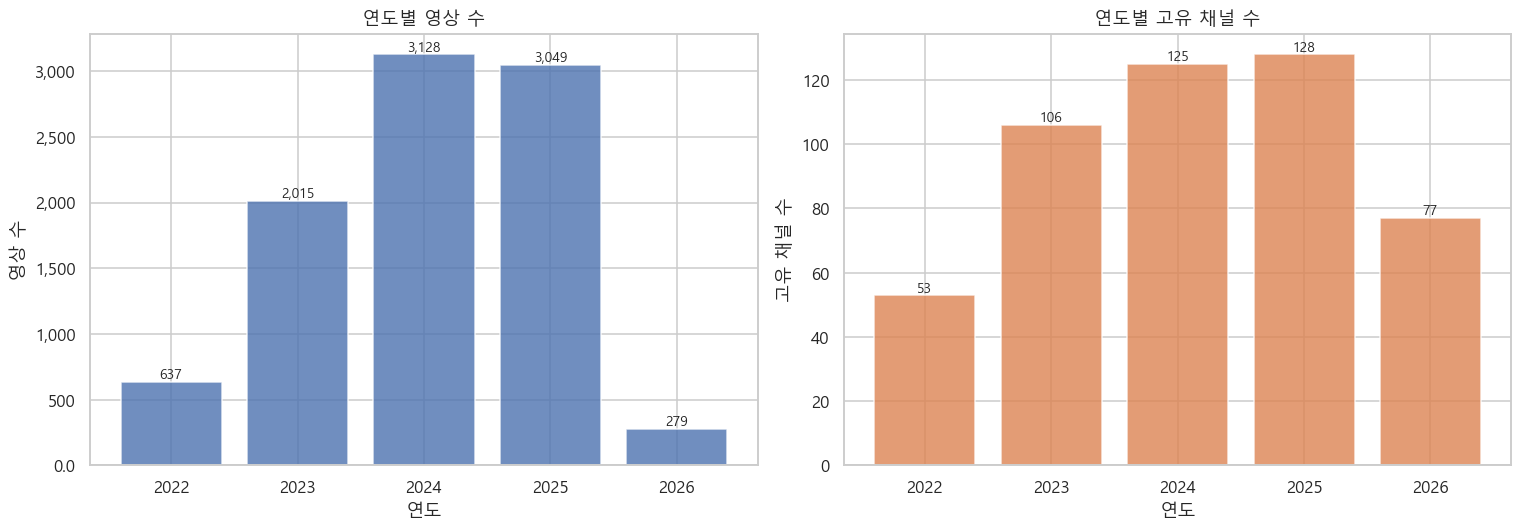

In [24]:
basic.eda_yearly_videos(df)

### 2-B. 피처 vs 조회수

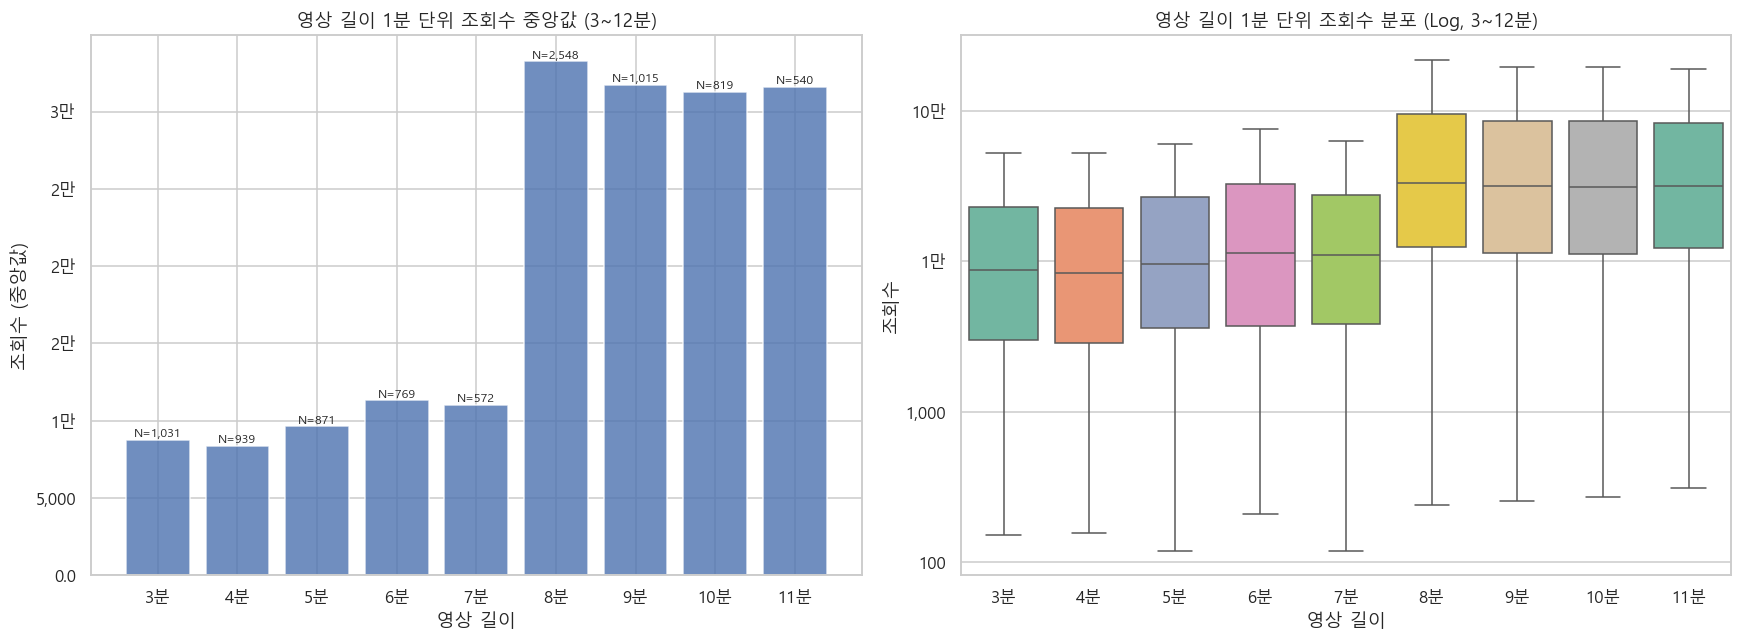

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_feature.py:105: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
C:\Users\COM\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


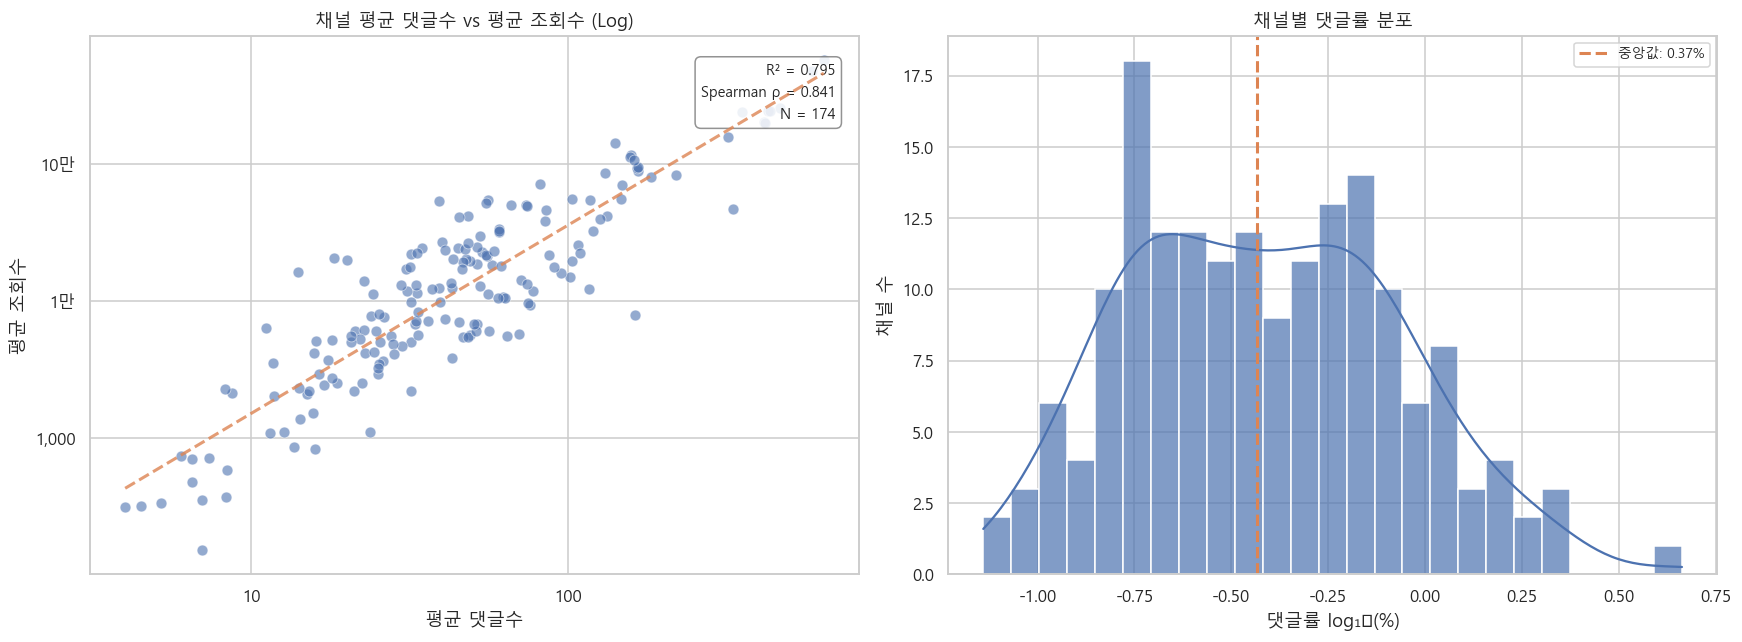

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_feature.py:143: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
C:\Users\COM\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


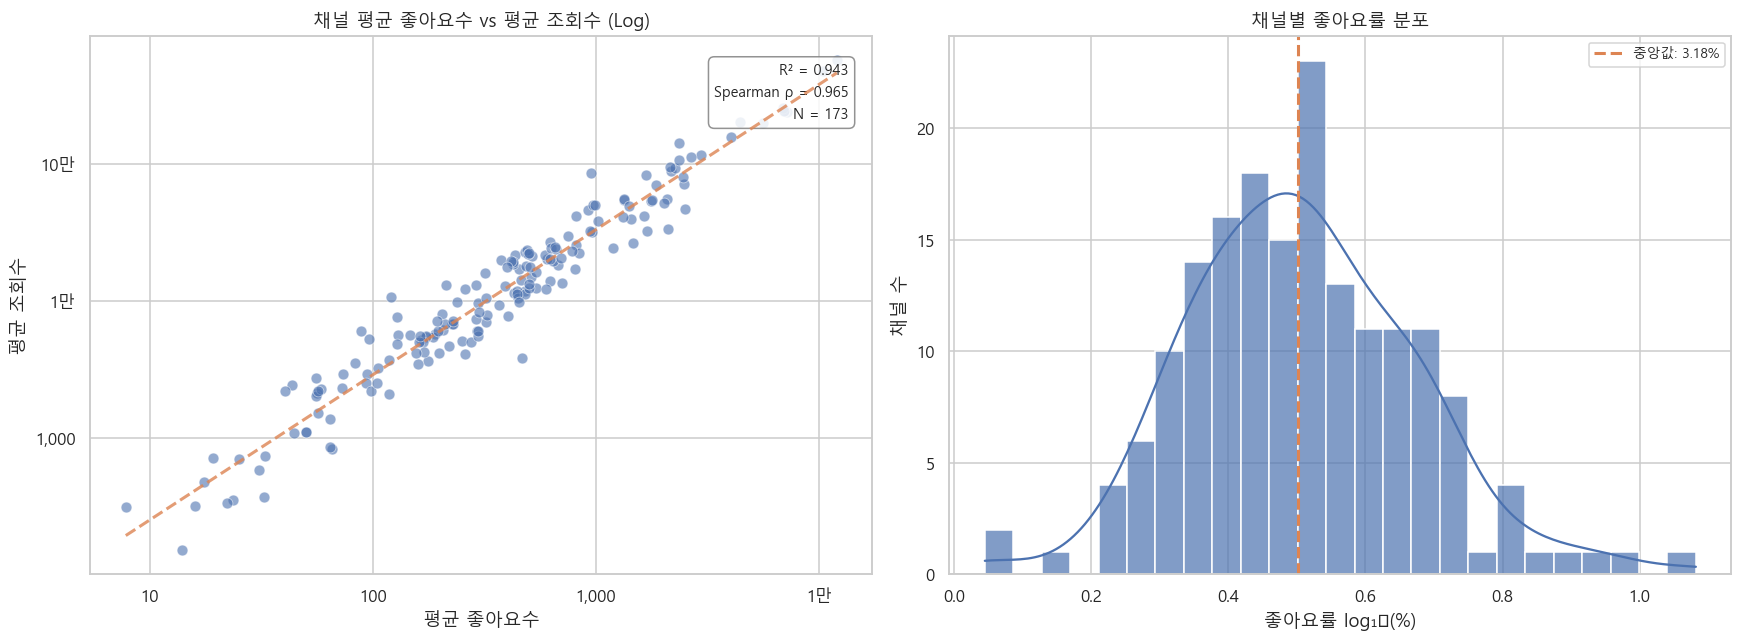

,category_id,category_name,n,median_view,mean_view
1,23,Comedy,900,28614.5,48033.137778
0,22,Lifestyle / Talk,4192,23735.5,88009.727815
2,24,Entertainment / Broadcast,4016,14563.0,28347.895169


D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_feature.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(cat_labels)


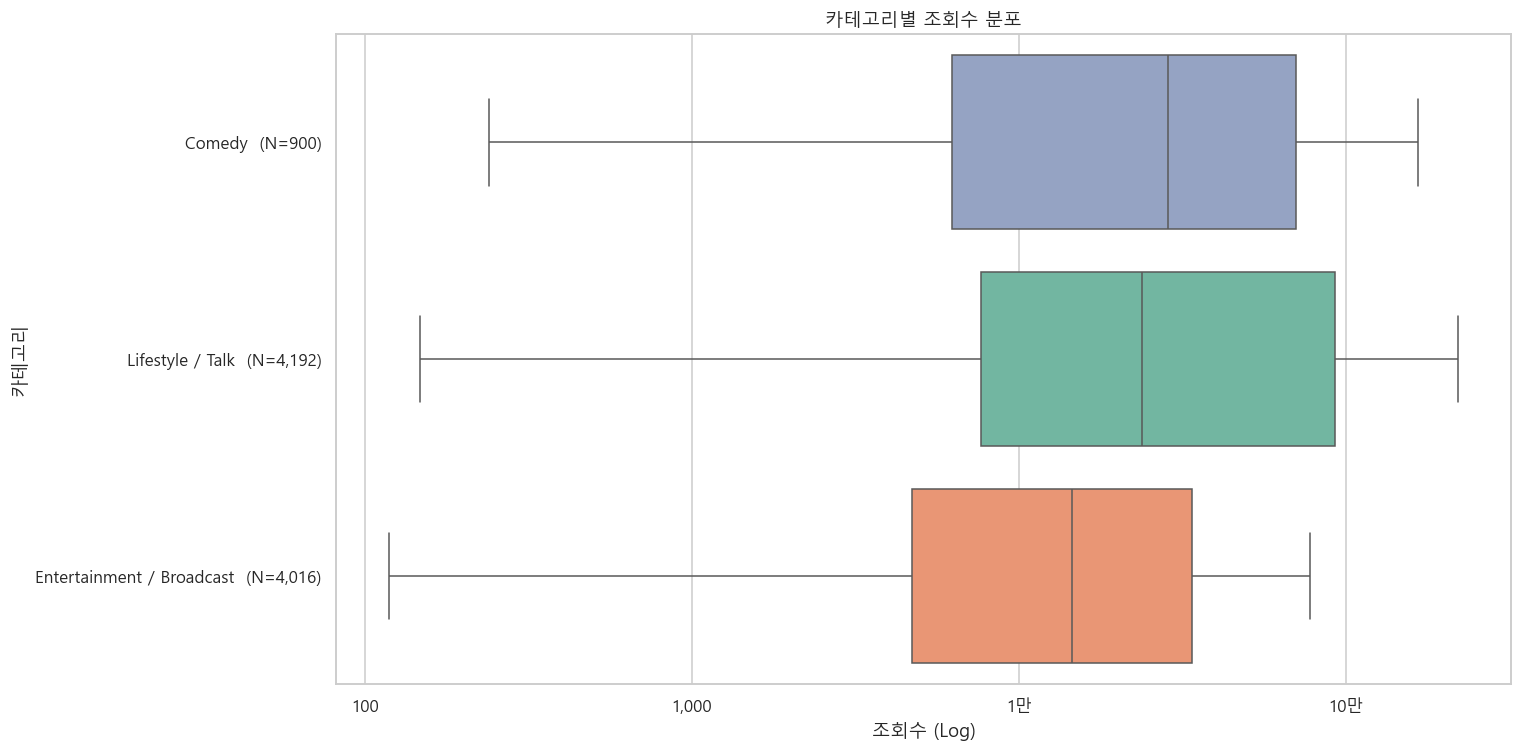

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_feature.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tag_labels, fontsize=9)


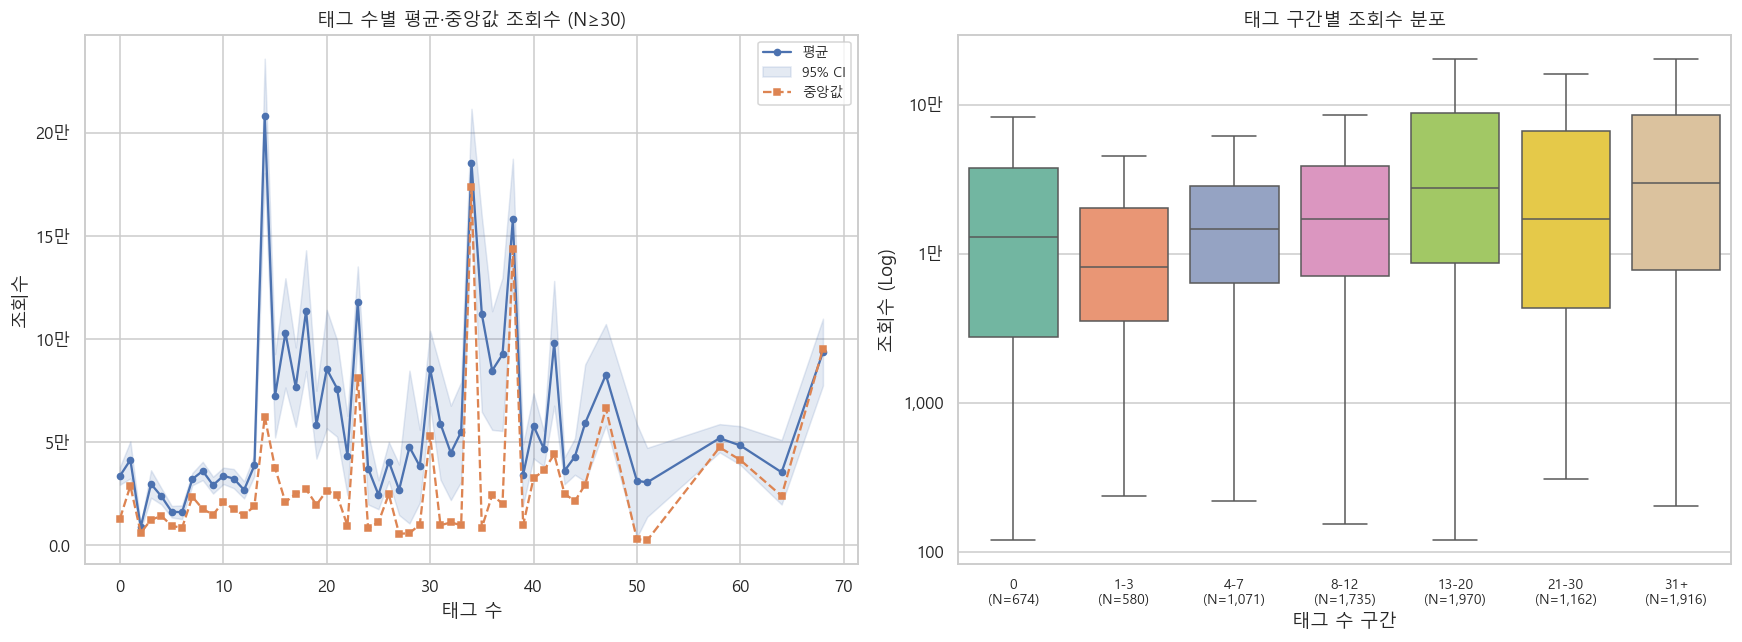

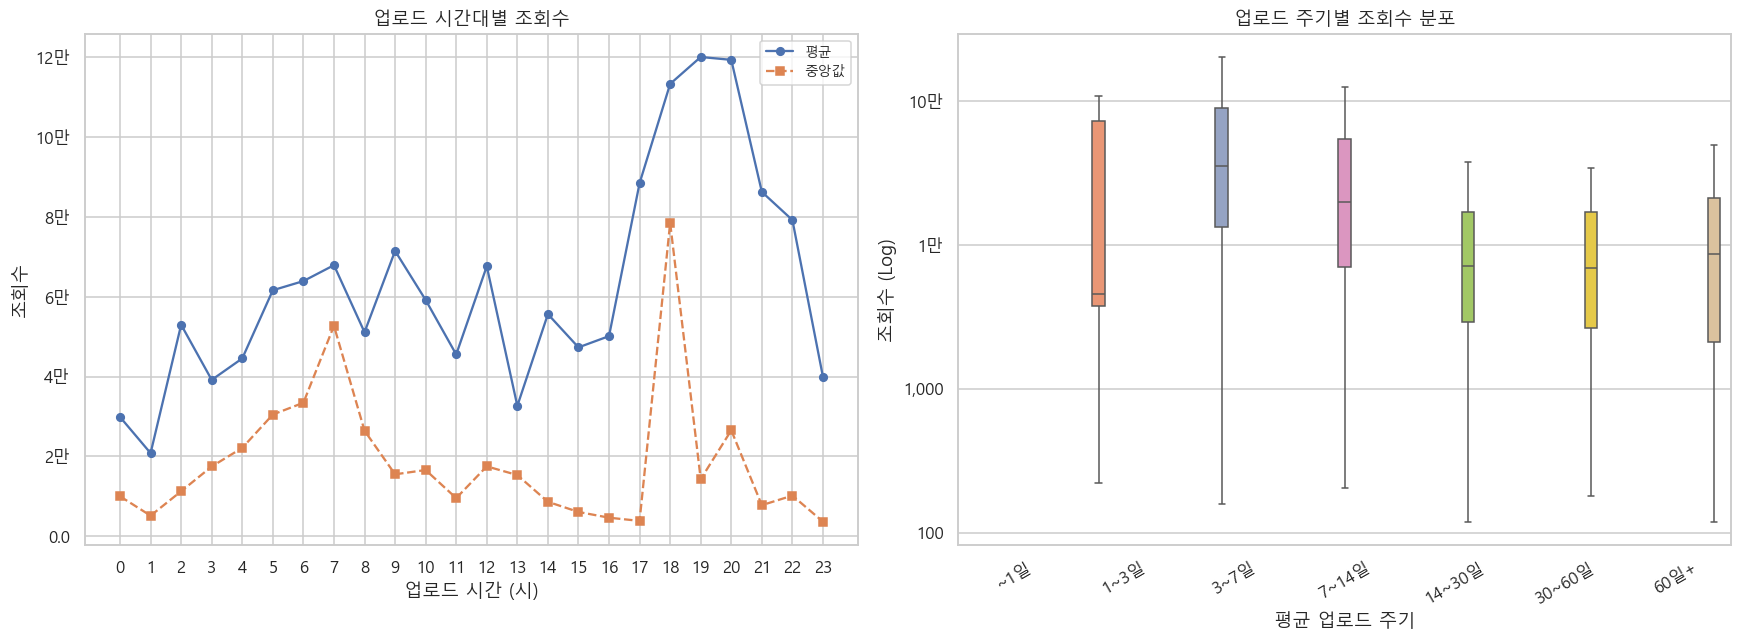

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_feature.py:280: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(score_labels, fontsize=9)


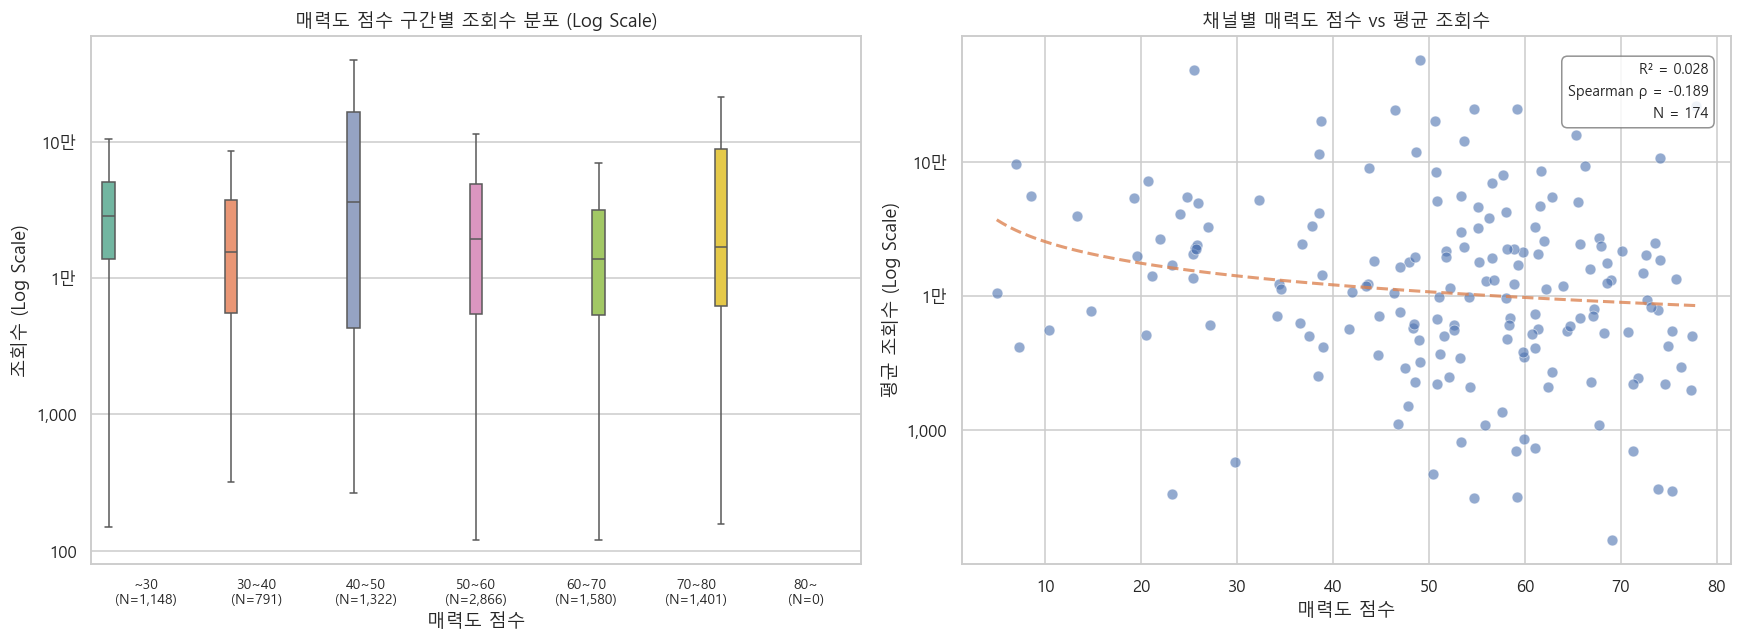

In [25]:
feat.eda_duration_vs_views(df)
feat.eda_comment_vs_views(df)
feat.eda_like_vs_views(df)
feat.eda_category_vs_views(df)
feat.eda_tag_count_vs_views(df)
feat.eda_upload_time_vs_views(df)
feat.eda_appearance_vs_views(df)

### 2-C. 선택된 피처 EDA

Spearman r 해석: |r|≥0.2 강함 / 0.1~0.2 약함 / <0.1 매우 약함


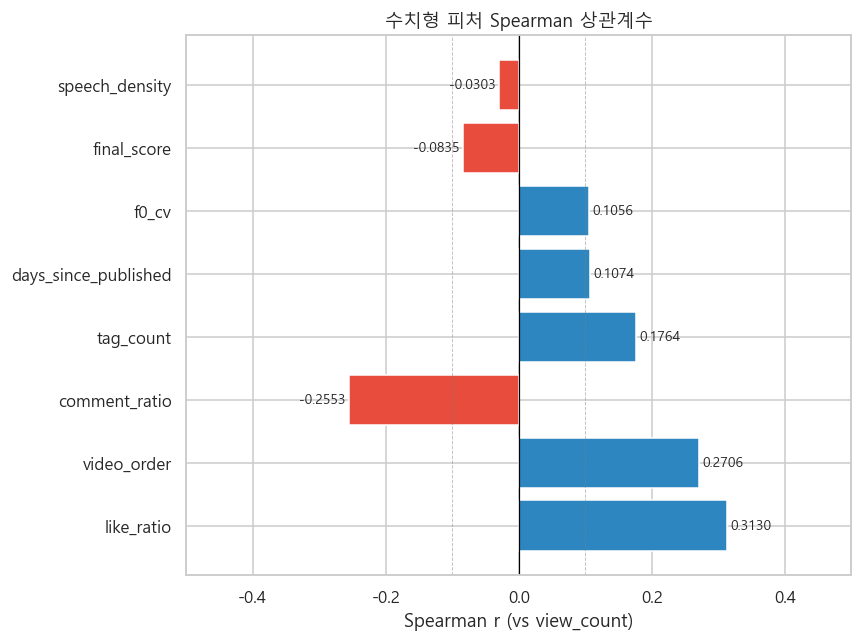

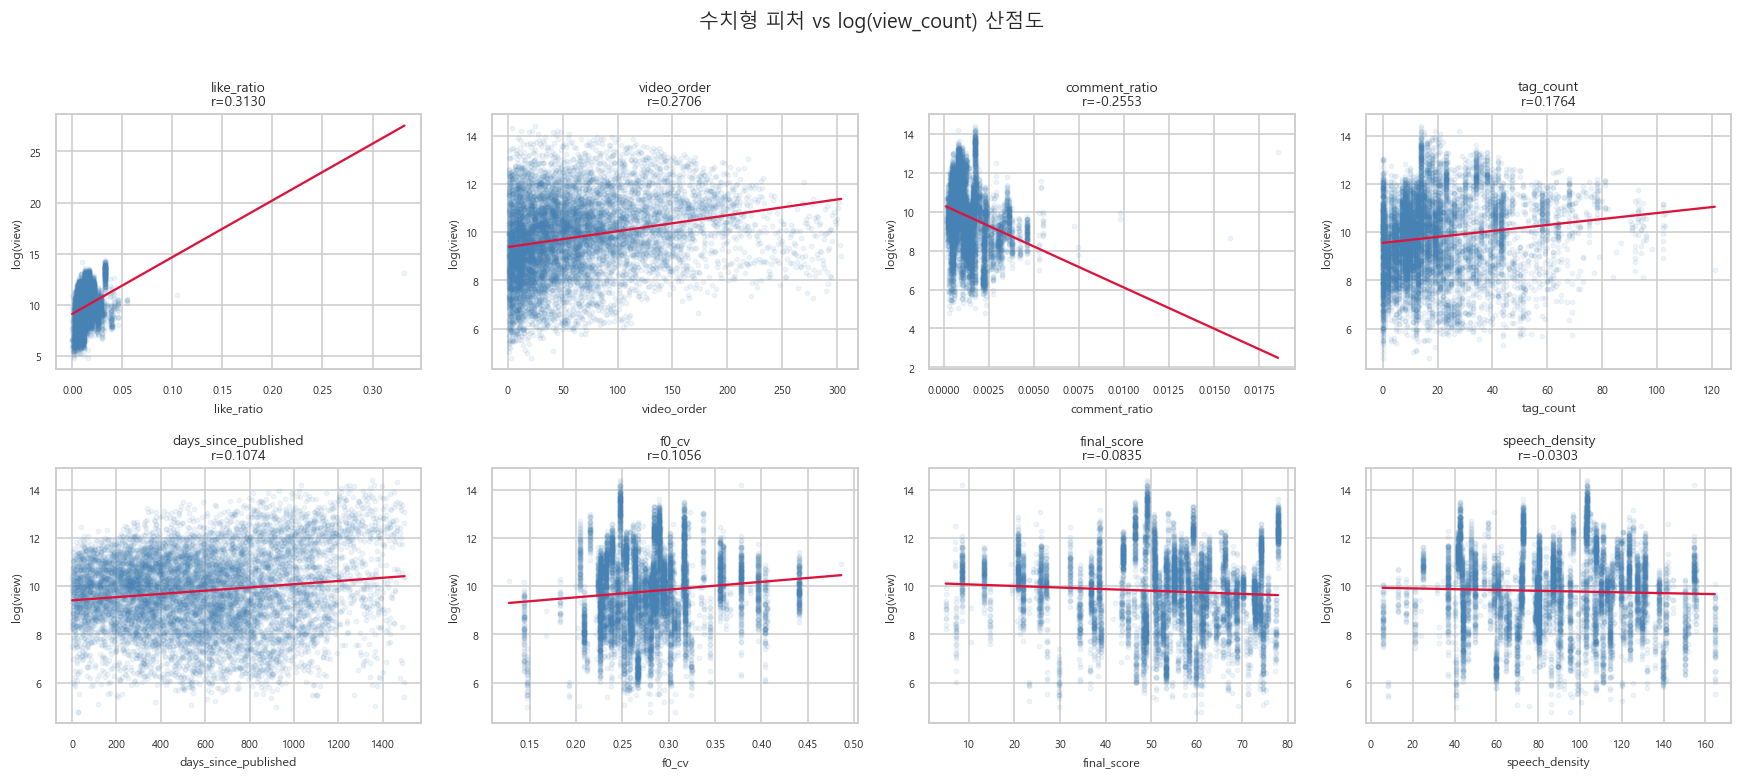

In [26]:
# Spearman 상관 분석
sel.eda_spearman_analysis(df)

CV 평균: 0.8564 (1 이상이면 그룹 내 분산 > 평균)
CV > 1인 그룹: 9개 / 36개


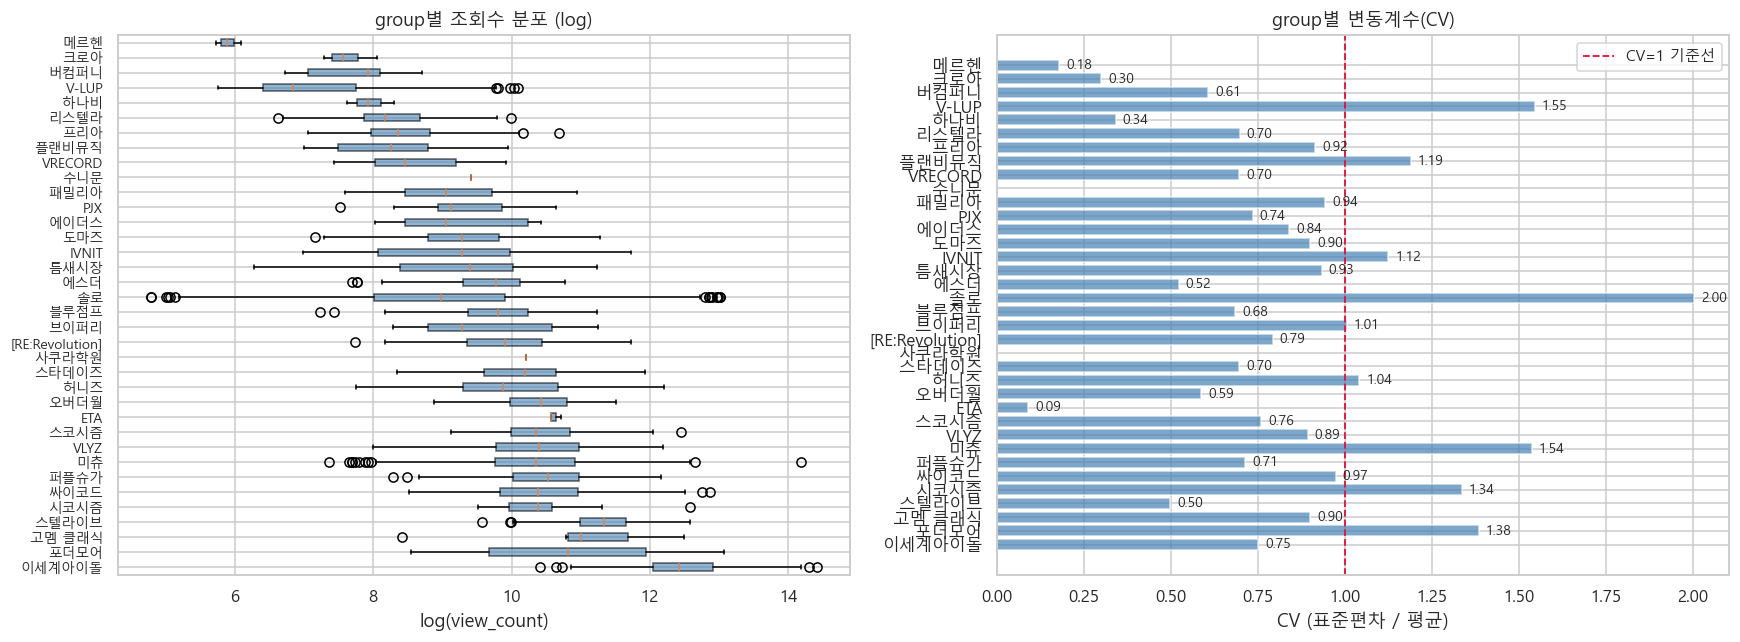

In [27]:
# group 피처
sel.eda_group_defense(df)

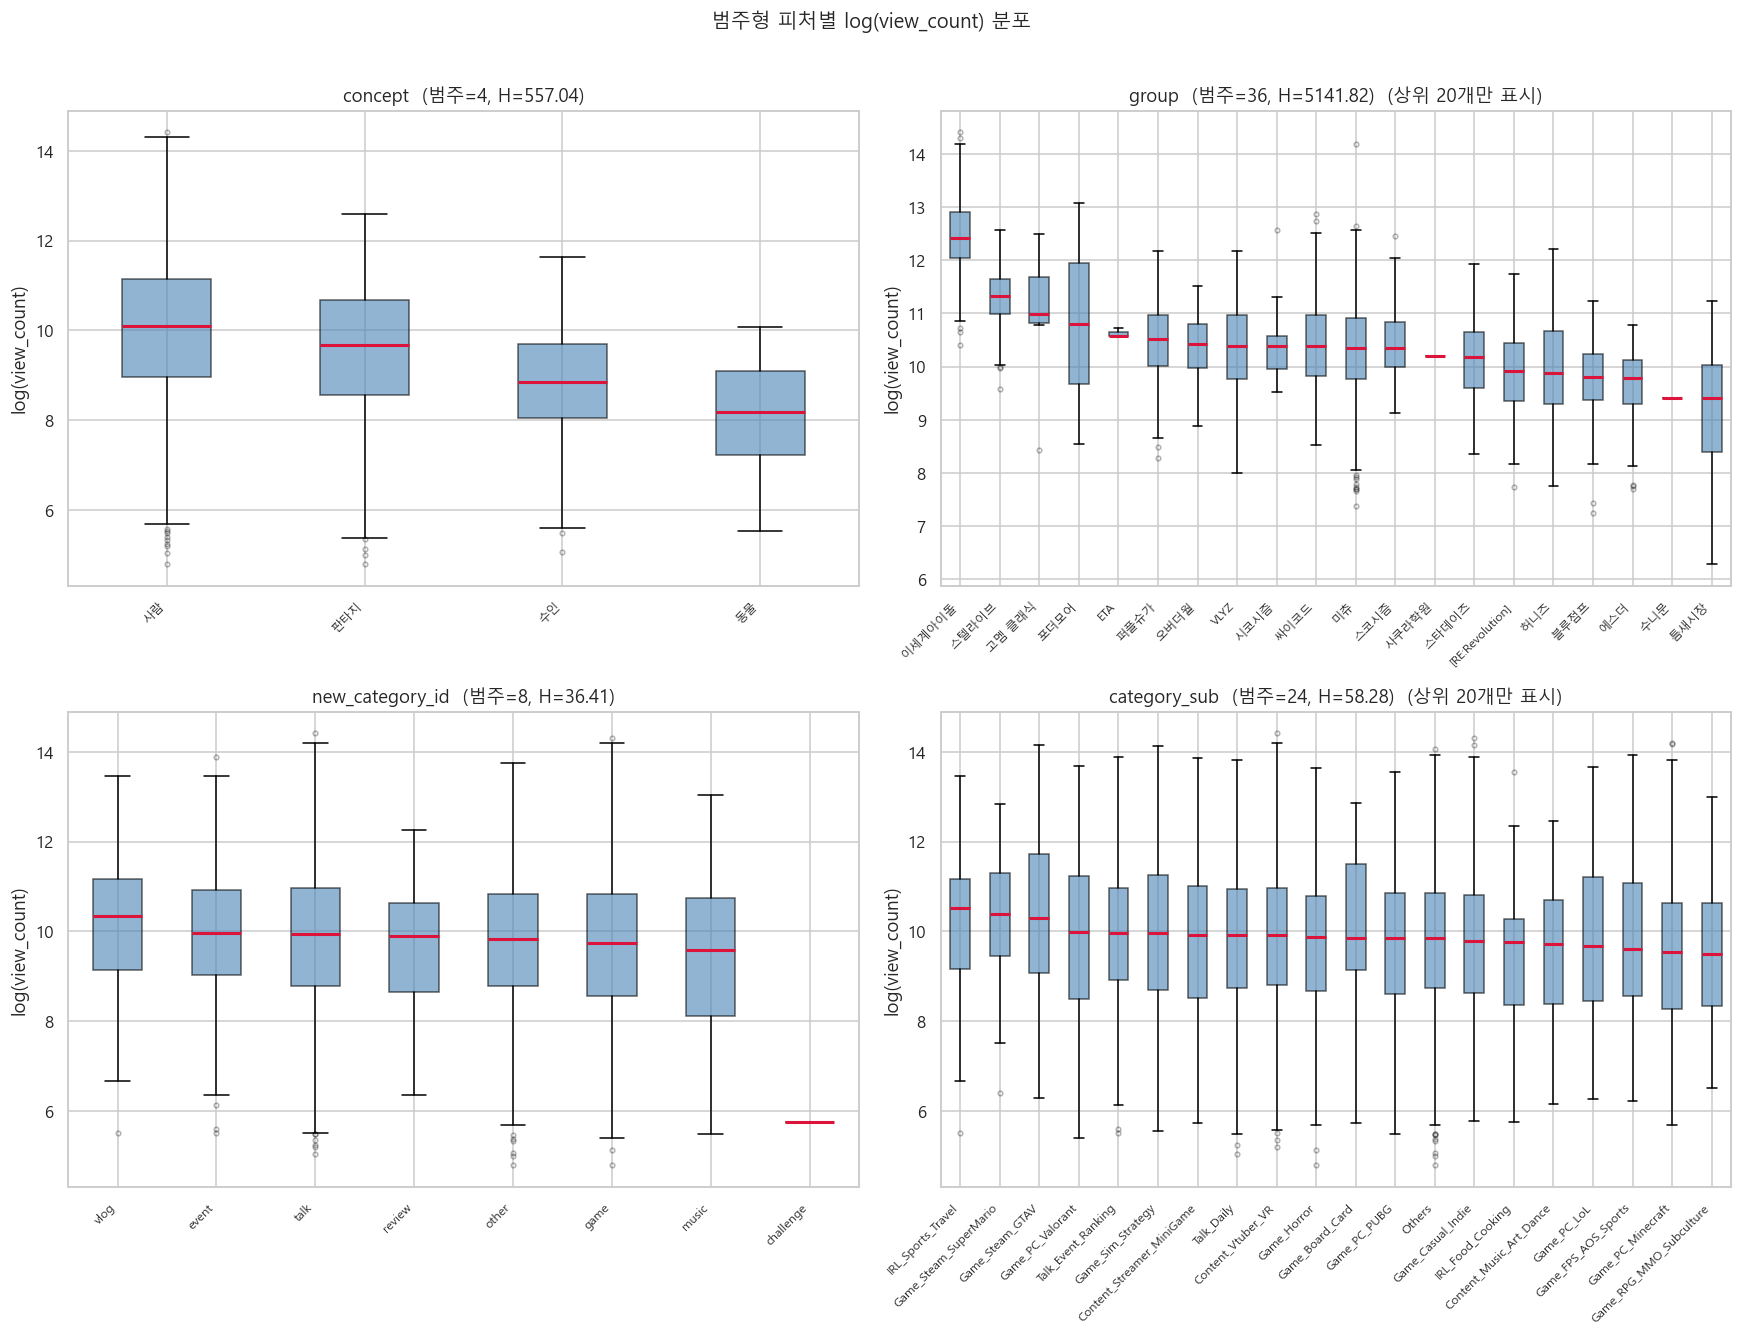

In [28]:
# 범주형 Kruskal-Wallis
sel.eda_kruskal_wallis(df)

In [29]:
# JNN 피처 생성 (df 전체를 train처럼 사용)
jnn_target_cols, jnn_agg_func_names = fe.get_jnn_params()
df_jnn = make_jnn_features(df, N=10, drop_insufficient=True,
                           target_cols=jnn_target_cols, agg_funcs=jnn_agg_func_names)
print(f'JNN 적용 후: {df_jnn.shape}')
print('JNN 피처:', [c for c in df_jnn.columns if c.startswith('jnn_')])

[make_jnn_features] NaN 행 5개 제거 (7698 → 7693)
JNN 적용 후: (7693, 100)
JNN 피처: ['jnn_like_count_cv', 'jnn_like_count_mean', 'jnn_like_count_momentum']


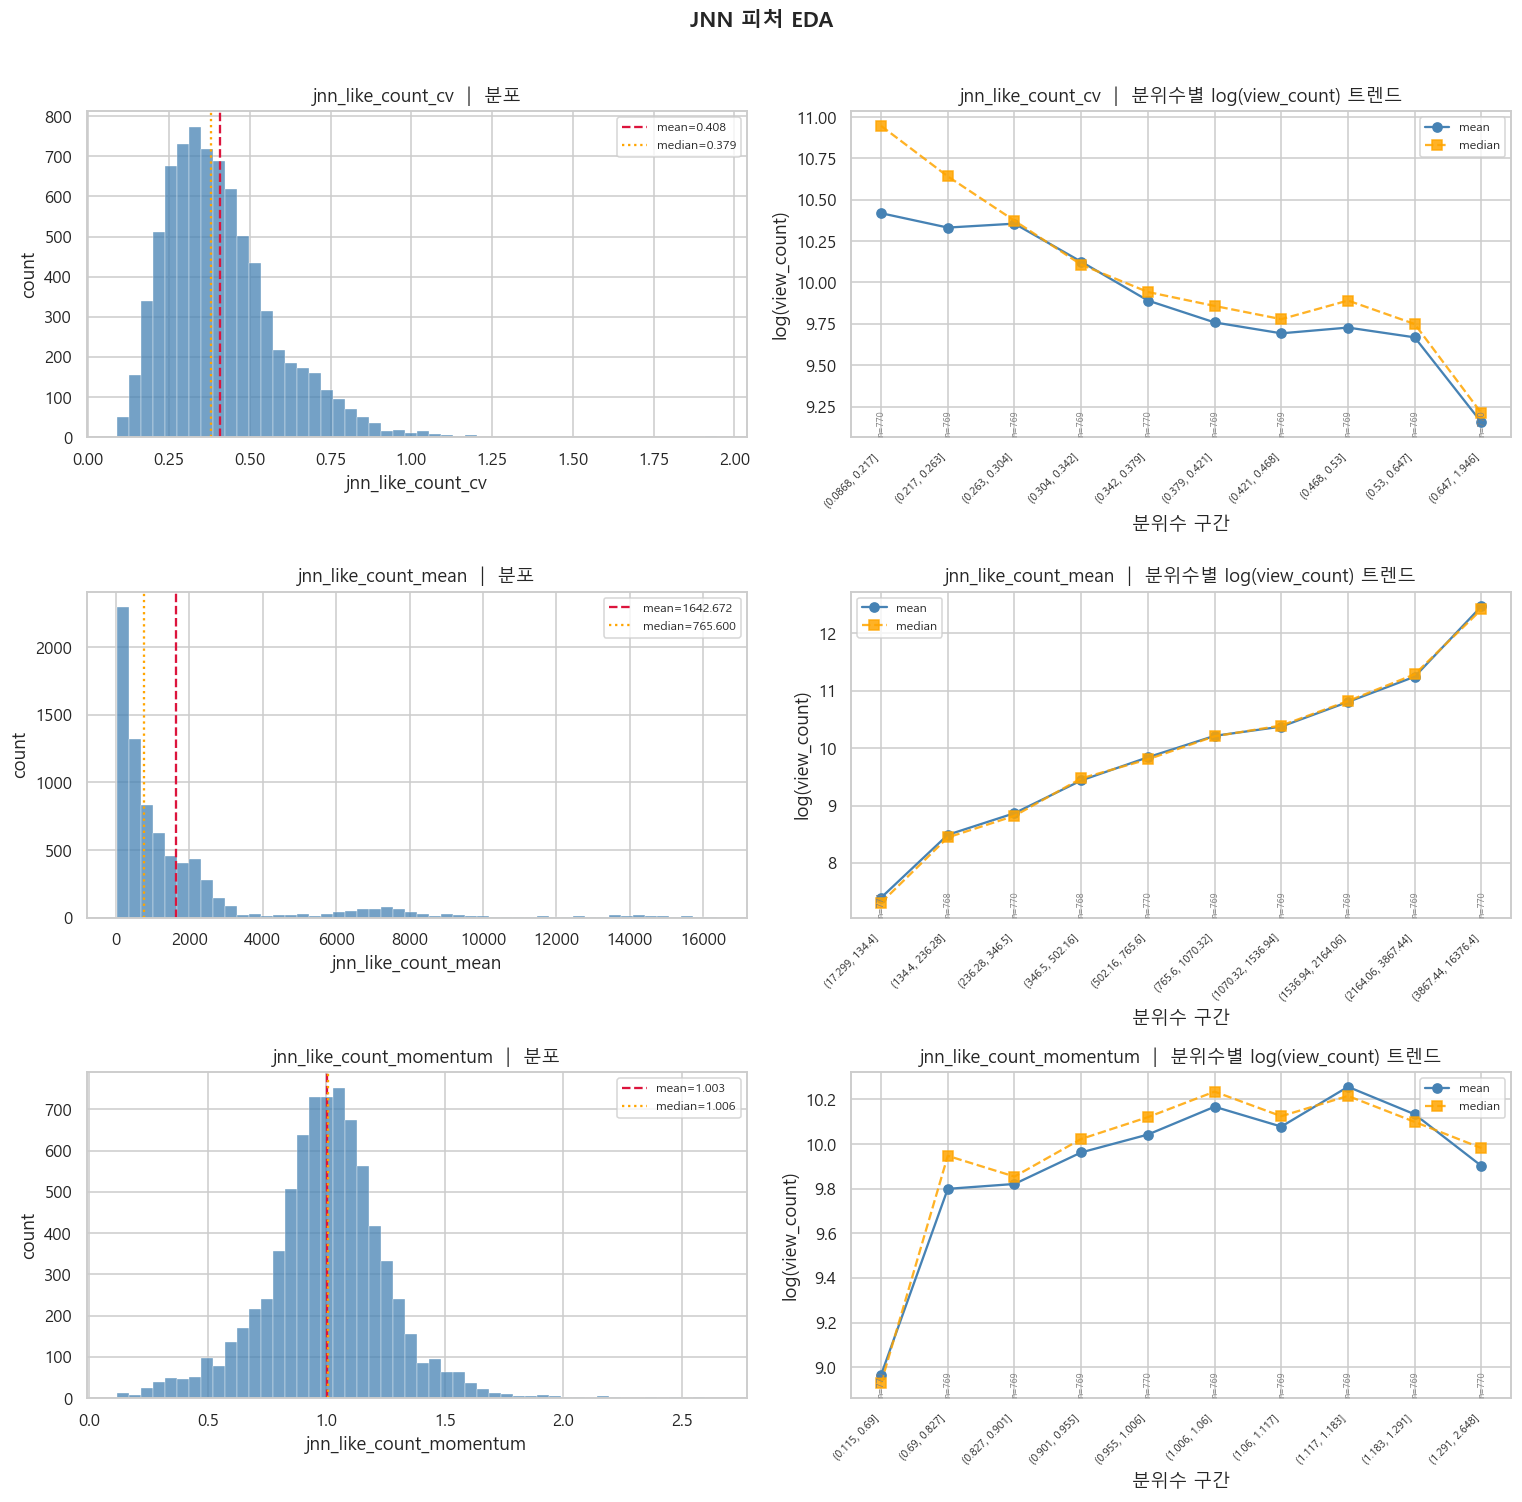

In [30]:
# JNN 피처 EDA
sel.eda_jnn_analysis(df_jnn)

### 2-D. 심화 분석

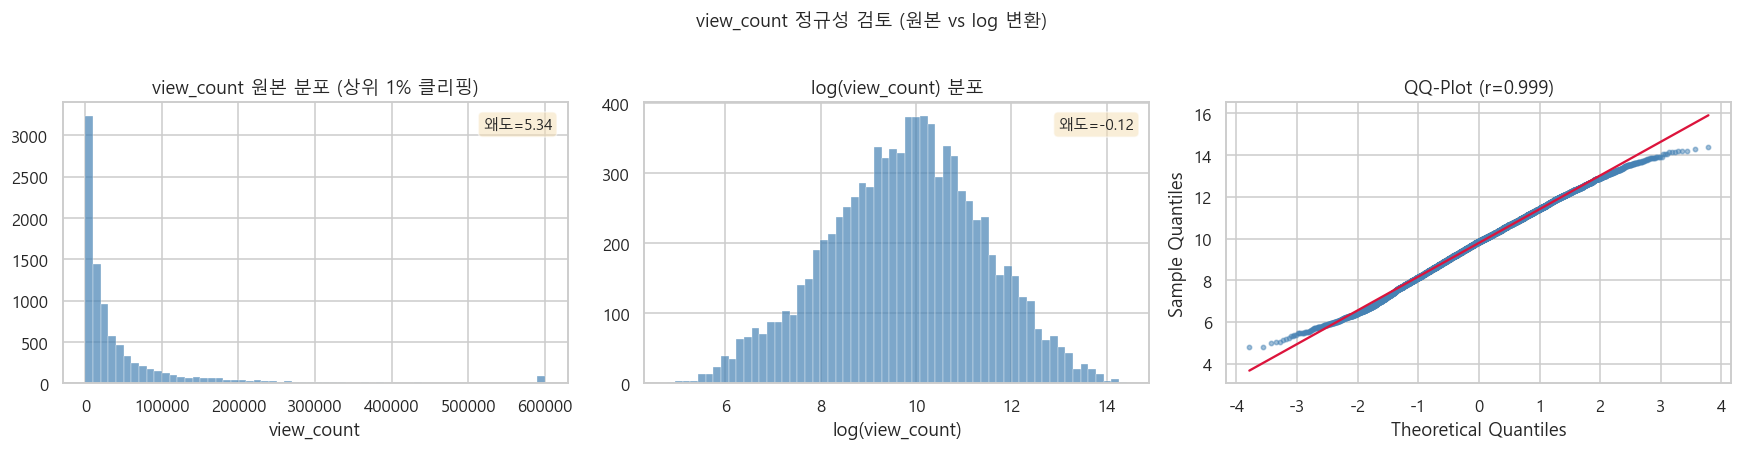

원본 왜도: 5.34 → log 변환 후: -0.12


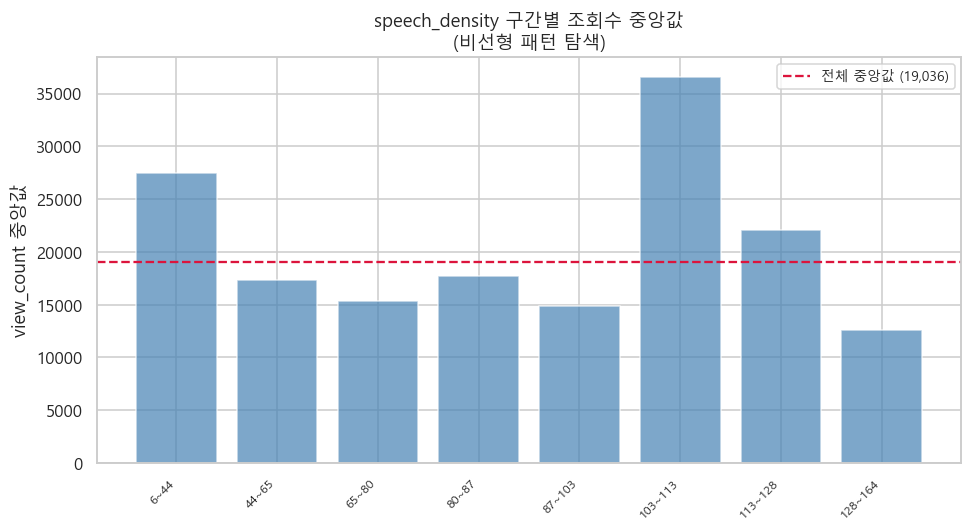

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_selection.py:292: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(sub[feature], sub['log_view'])
D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_selection.py:307: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(sub[feature], sub['log_view'], 1)


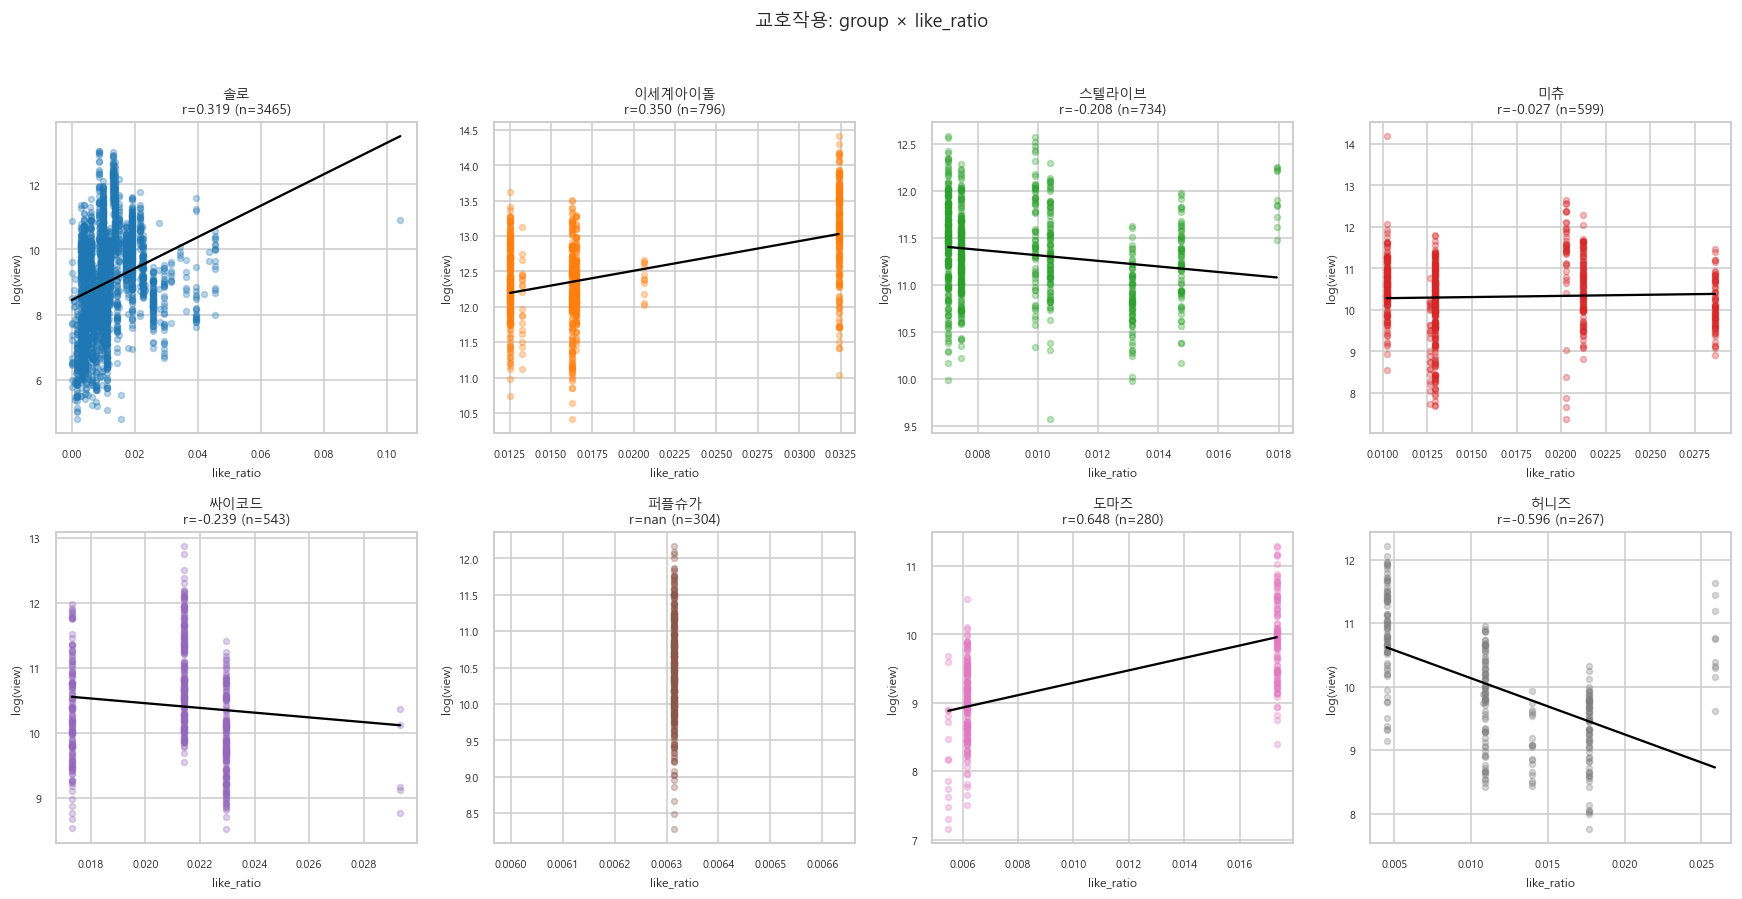

그룹별 like_ratio ↔ log(view) Spearman r:
  이세계아이돌              : r = +0.350
  솔로                  : r = +0.319
  싸이코드                : r = -0.239
  스텔라이브               : r = -0.208
  미츄                  : r = -0.027
  퍼플슈가                : r = +nan
  도마즈                 : r = +0.648
  허니즈                 : r = -0.596

전체 Spearman r = 0.365


D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_selection.py:292: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(sub[feature], sub['log_view'])
D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_selection.py:307: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(sub[feature], sub['log_view'], 1)


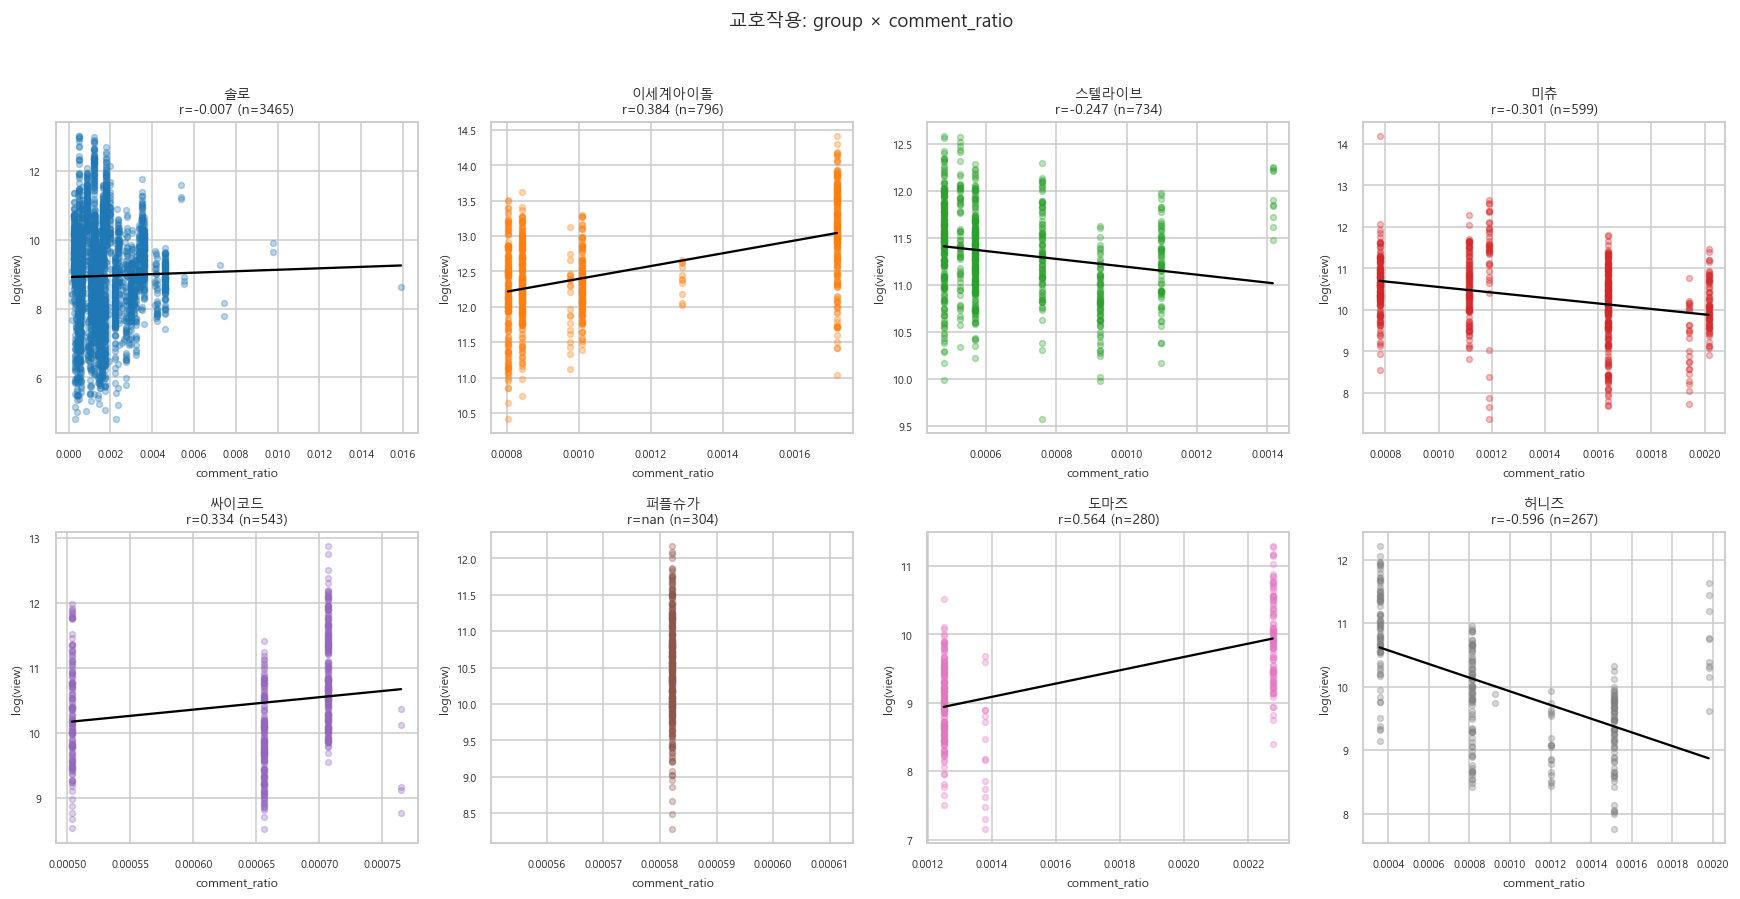

그룹별 comment_ratio ↔ log(view) Spearman r:
  퍼플슈가                : r = +nan
  허니즈                 : r = -0.596
  도마즈                 : r = +0.564
  이세계아이돌              : r = +0.384
  싸이코드                : r = +0.334
  미츄                  : r = -0.301
  스텔라이브               : r = -0.247
  솔로                  : r = -0.007

전체 Spearman r = -0.204


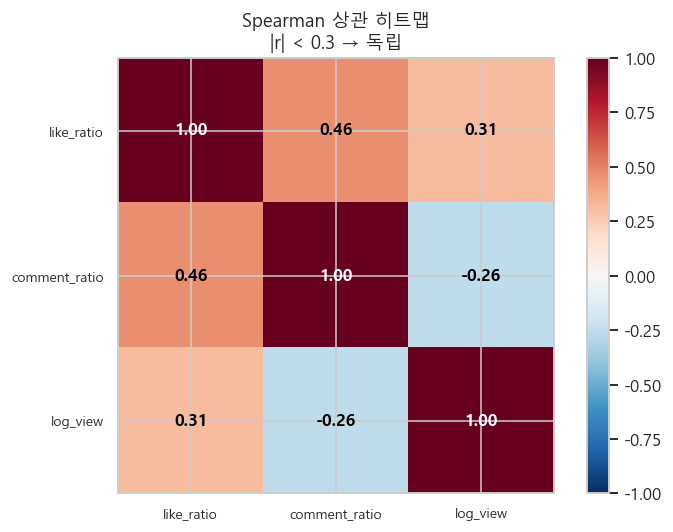

=== 피처 간 Spearman r ===
  like_ratio ↔ comment_ratio: r=+0.464  △ 약한 관련


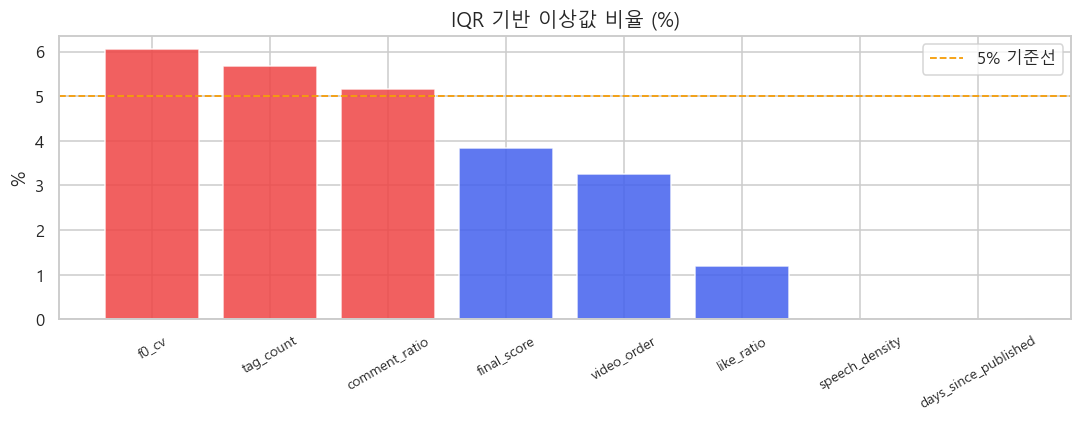

In [31]:
sel.eda_target_distribution(df)
sel.eda_speech_density_nonlinear(df)
sel.eda_interaction(df, feature='like_ratio')
sel.eda_interaction(df, feature='comment_ratio')
sel.eda_feature_independence(df)
basic.plot_outlier_summary(df)

### 2-F. 썸네일 피처 EDA


  overview
[썸네일 피처 개요] N=9,108


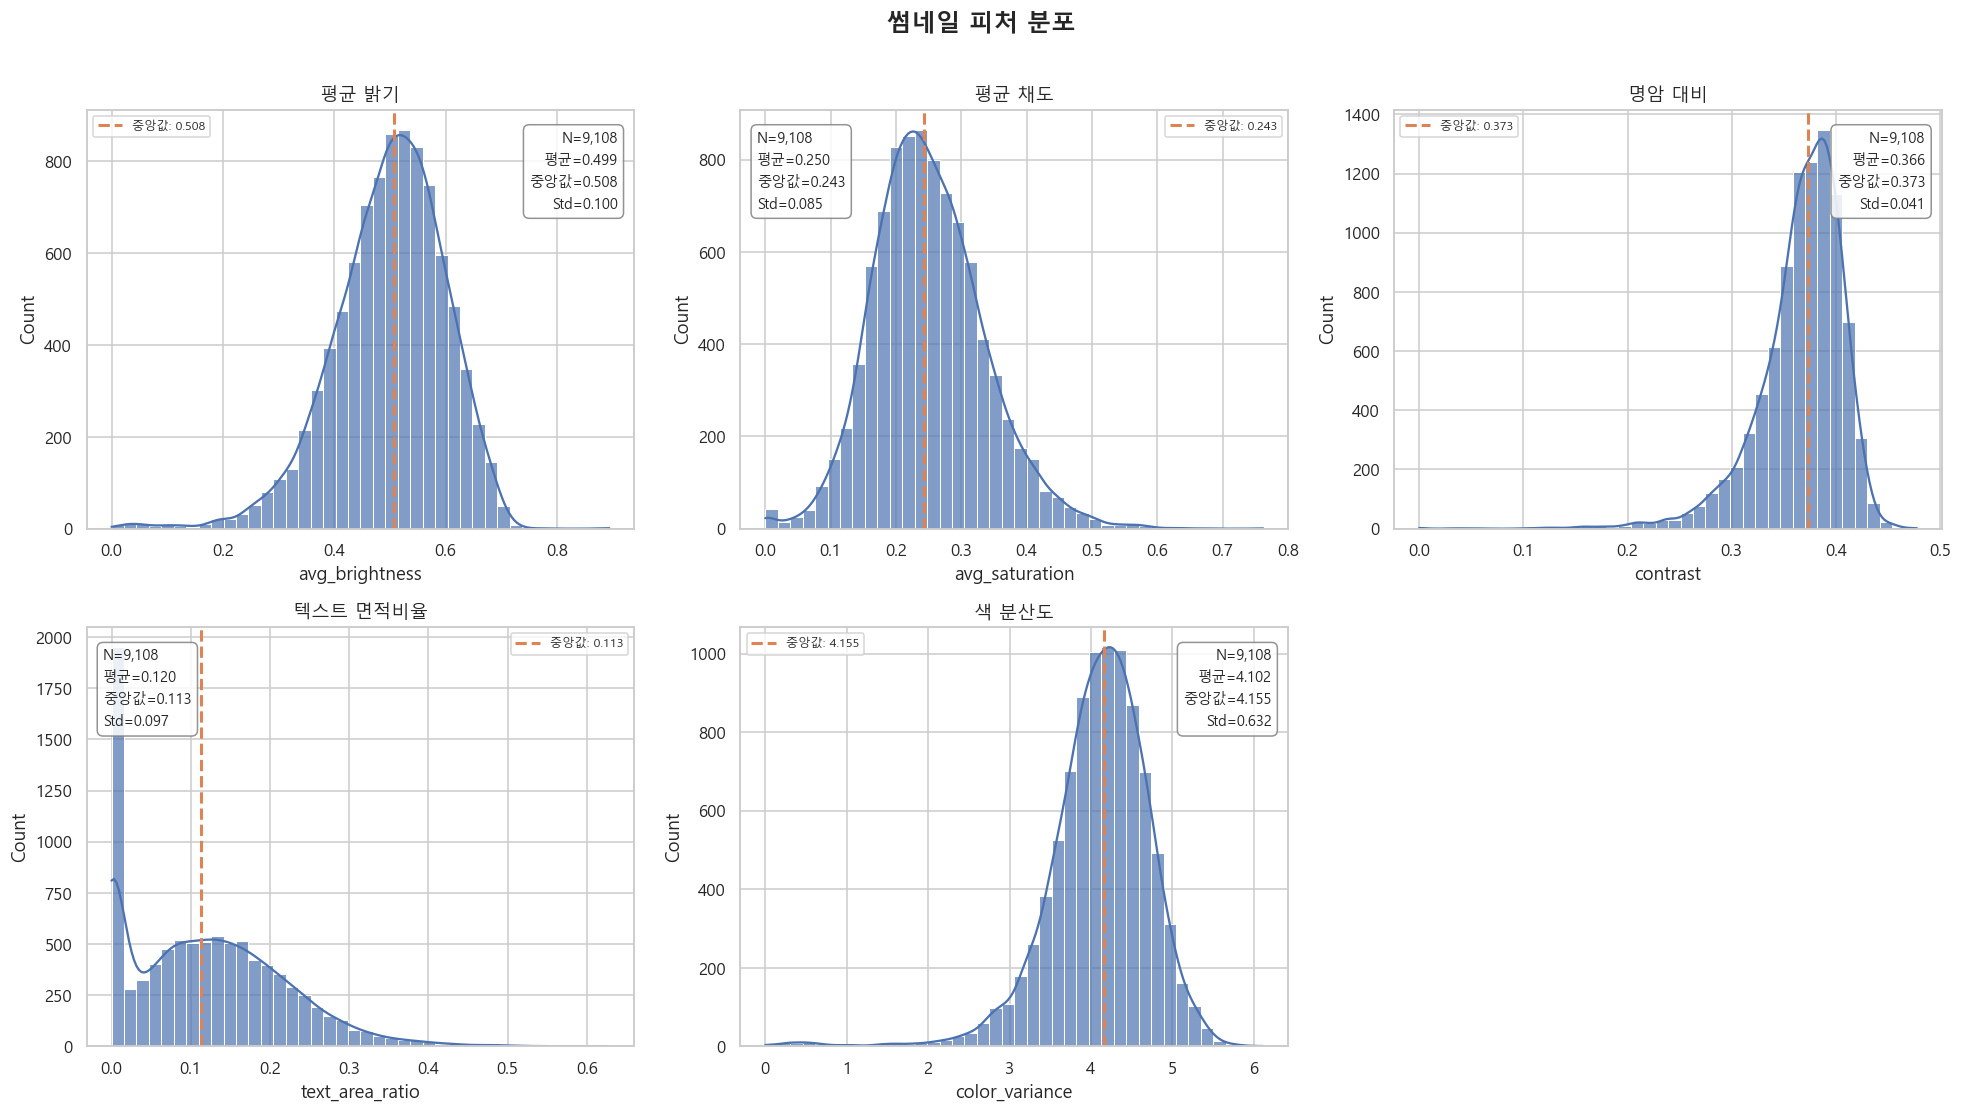


  correlation


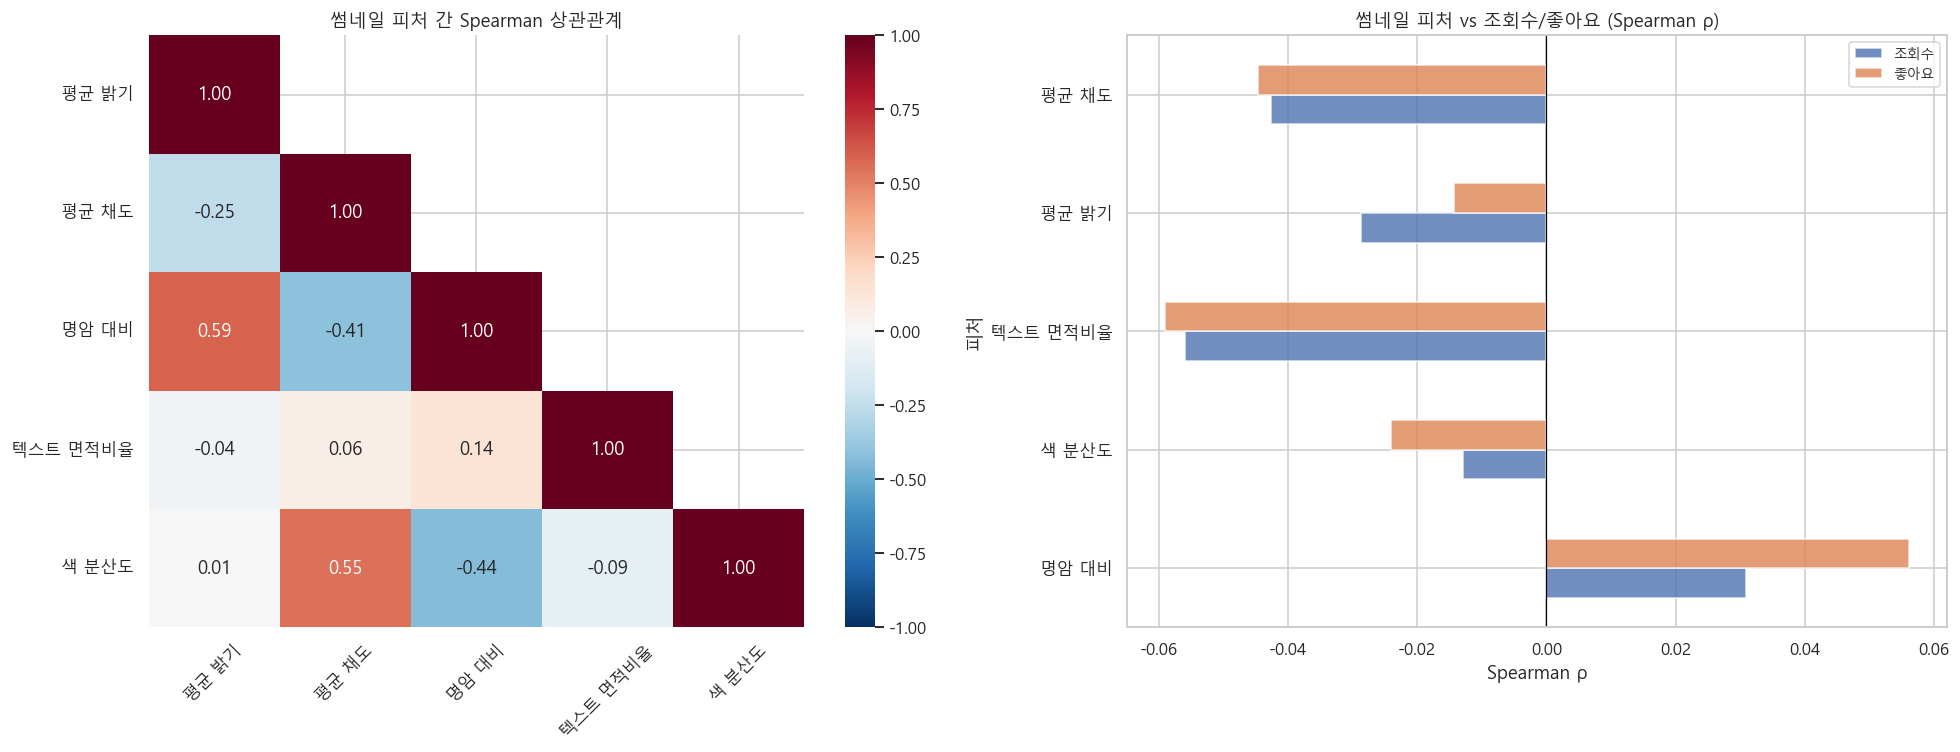


  vs_views


D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_thumb.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=8)


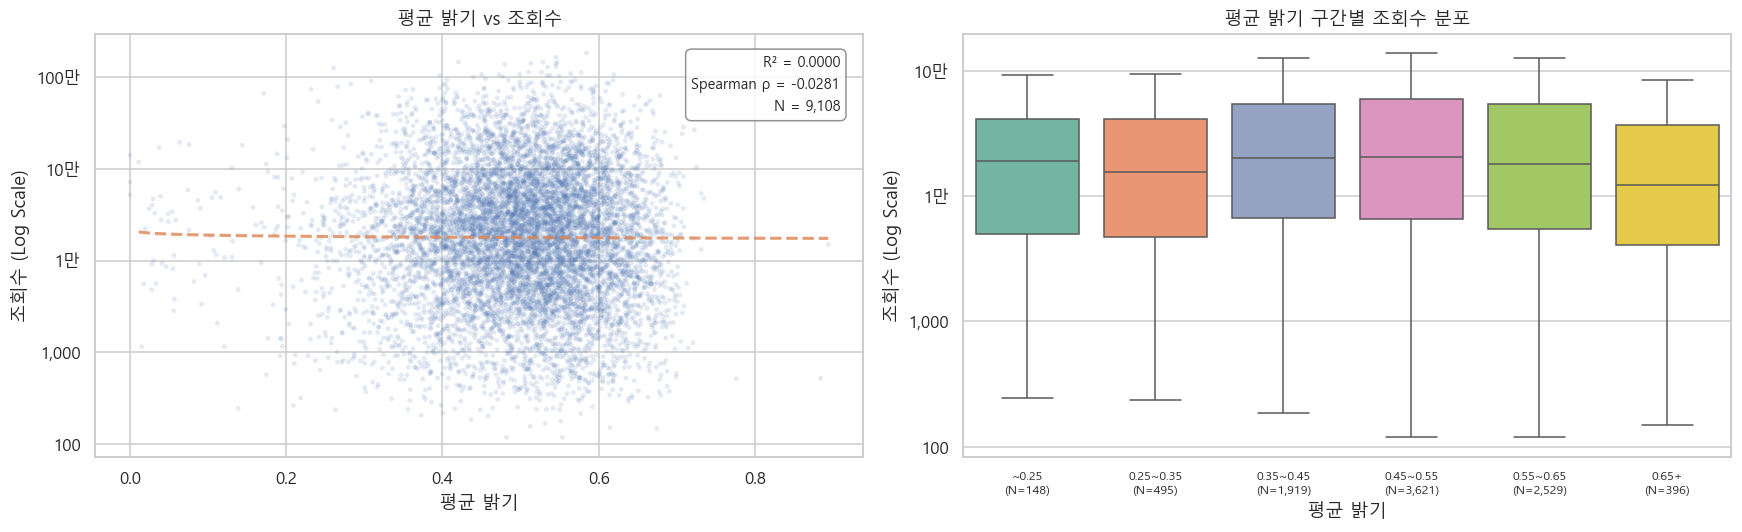

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_thumb.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=8)


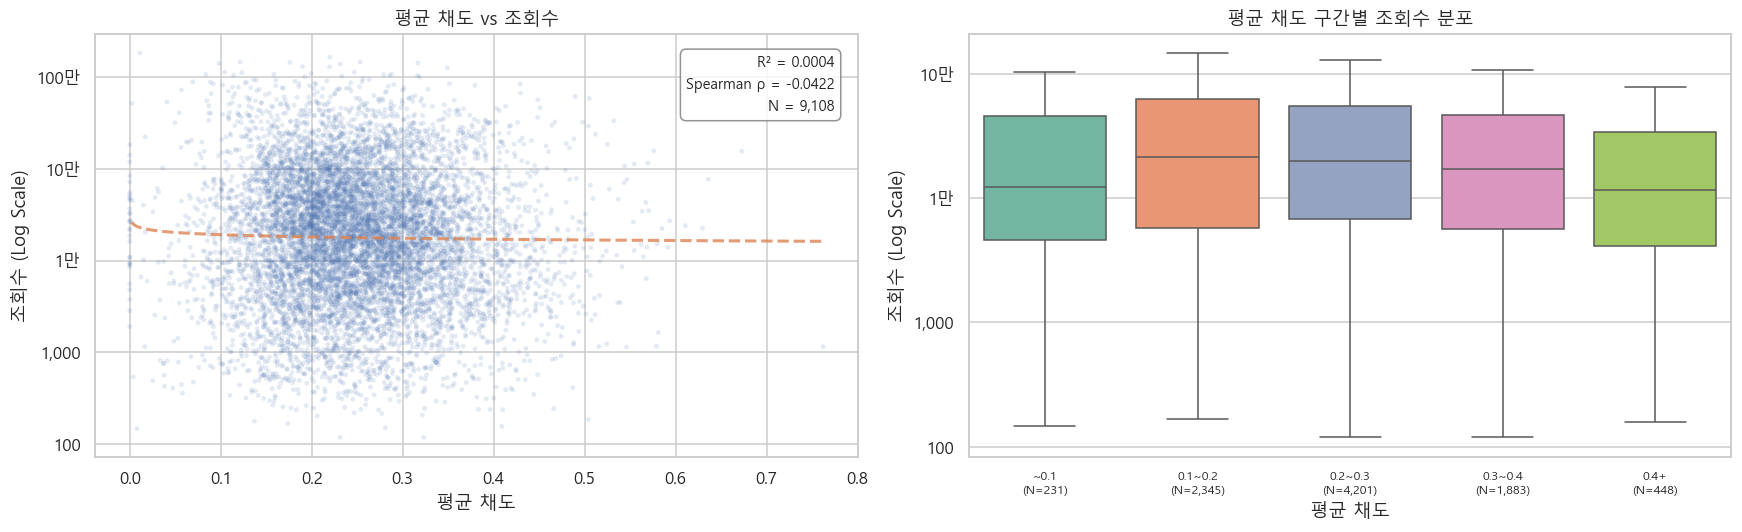

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_thumb.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=8)


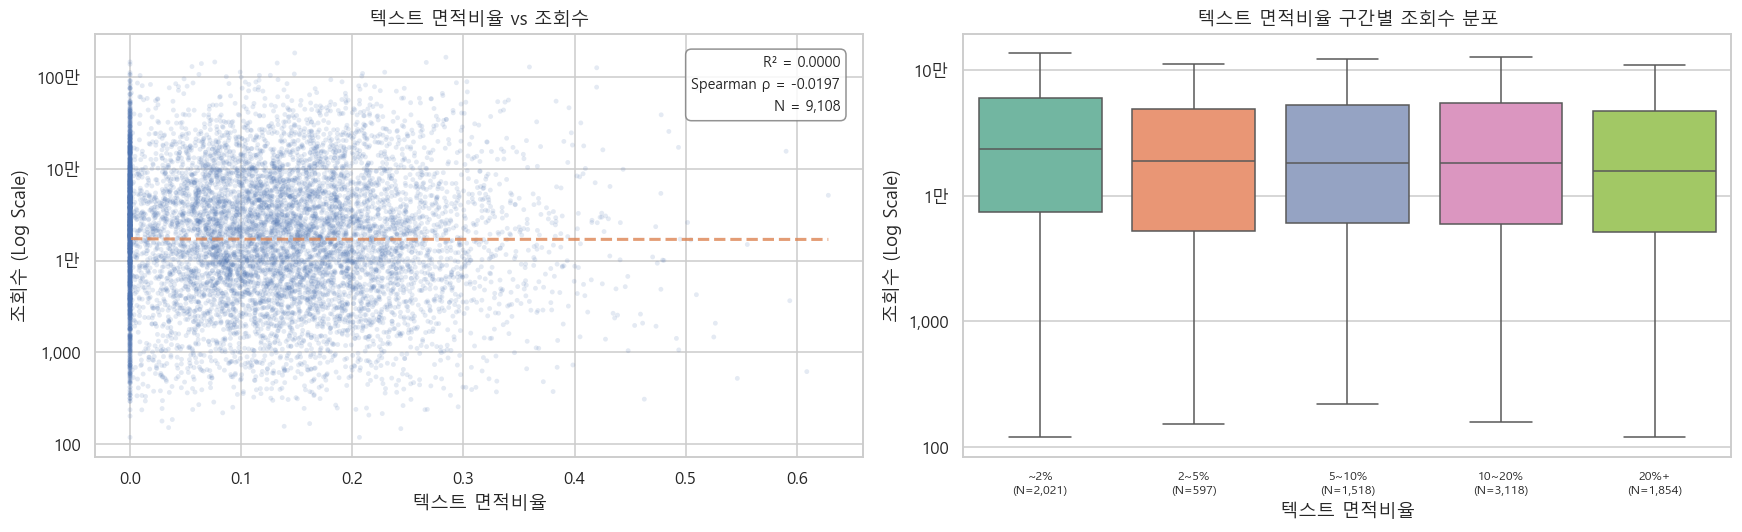

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_thumb.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=8)


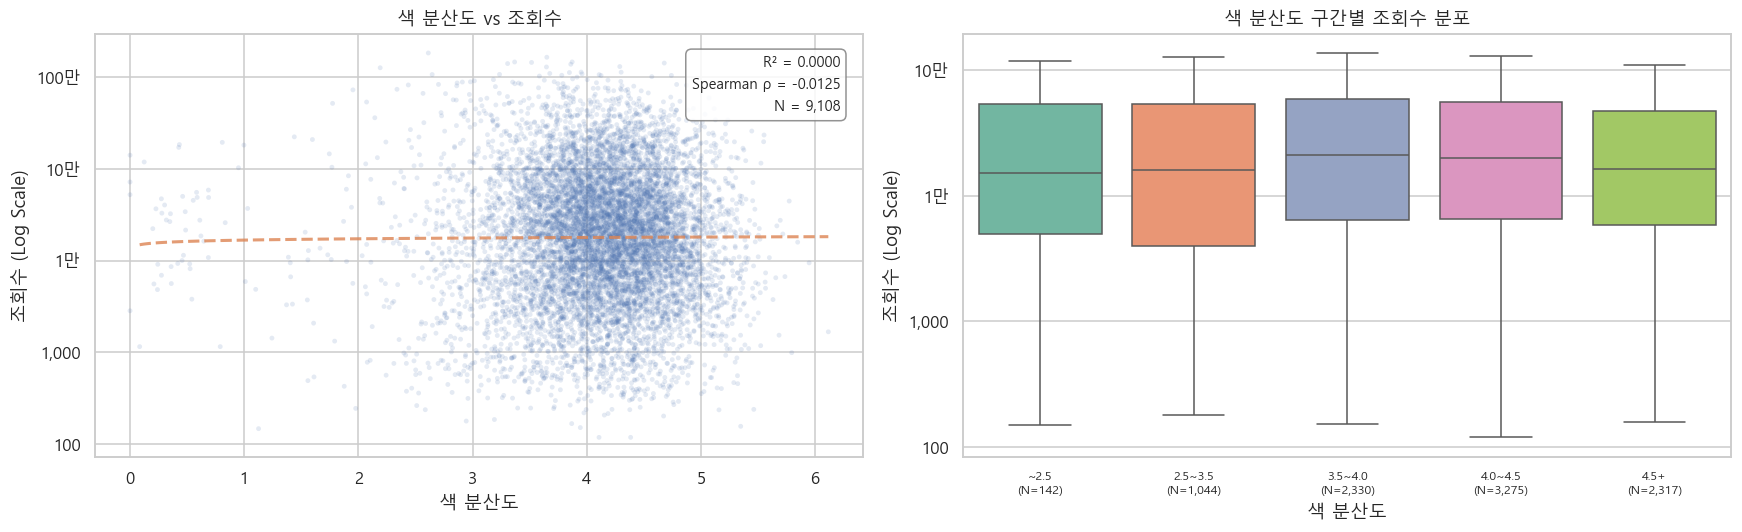


  channel
[채널 단위 집계] 채널 수: 174


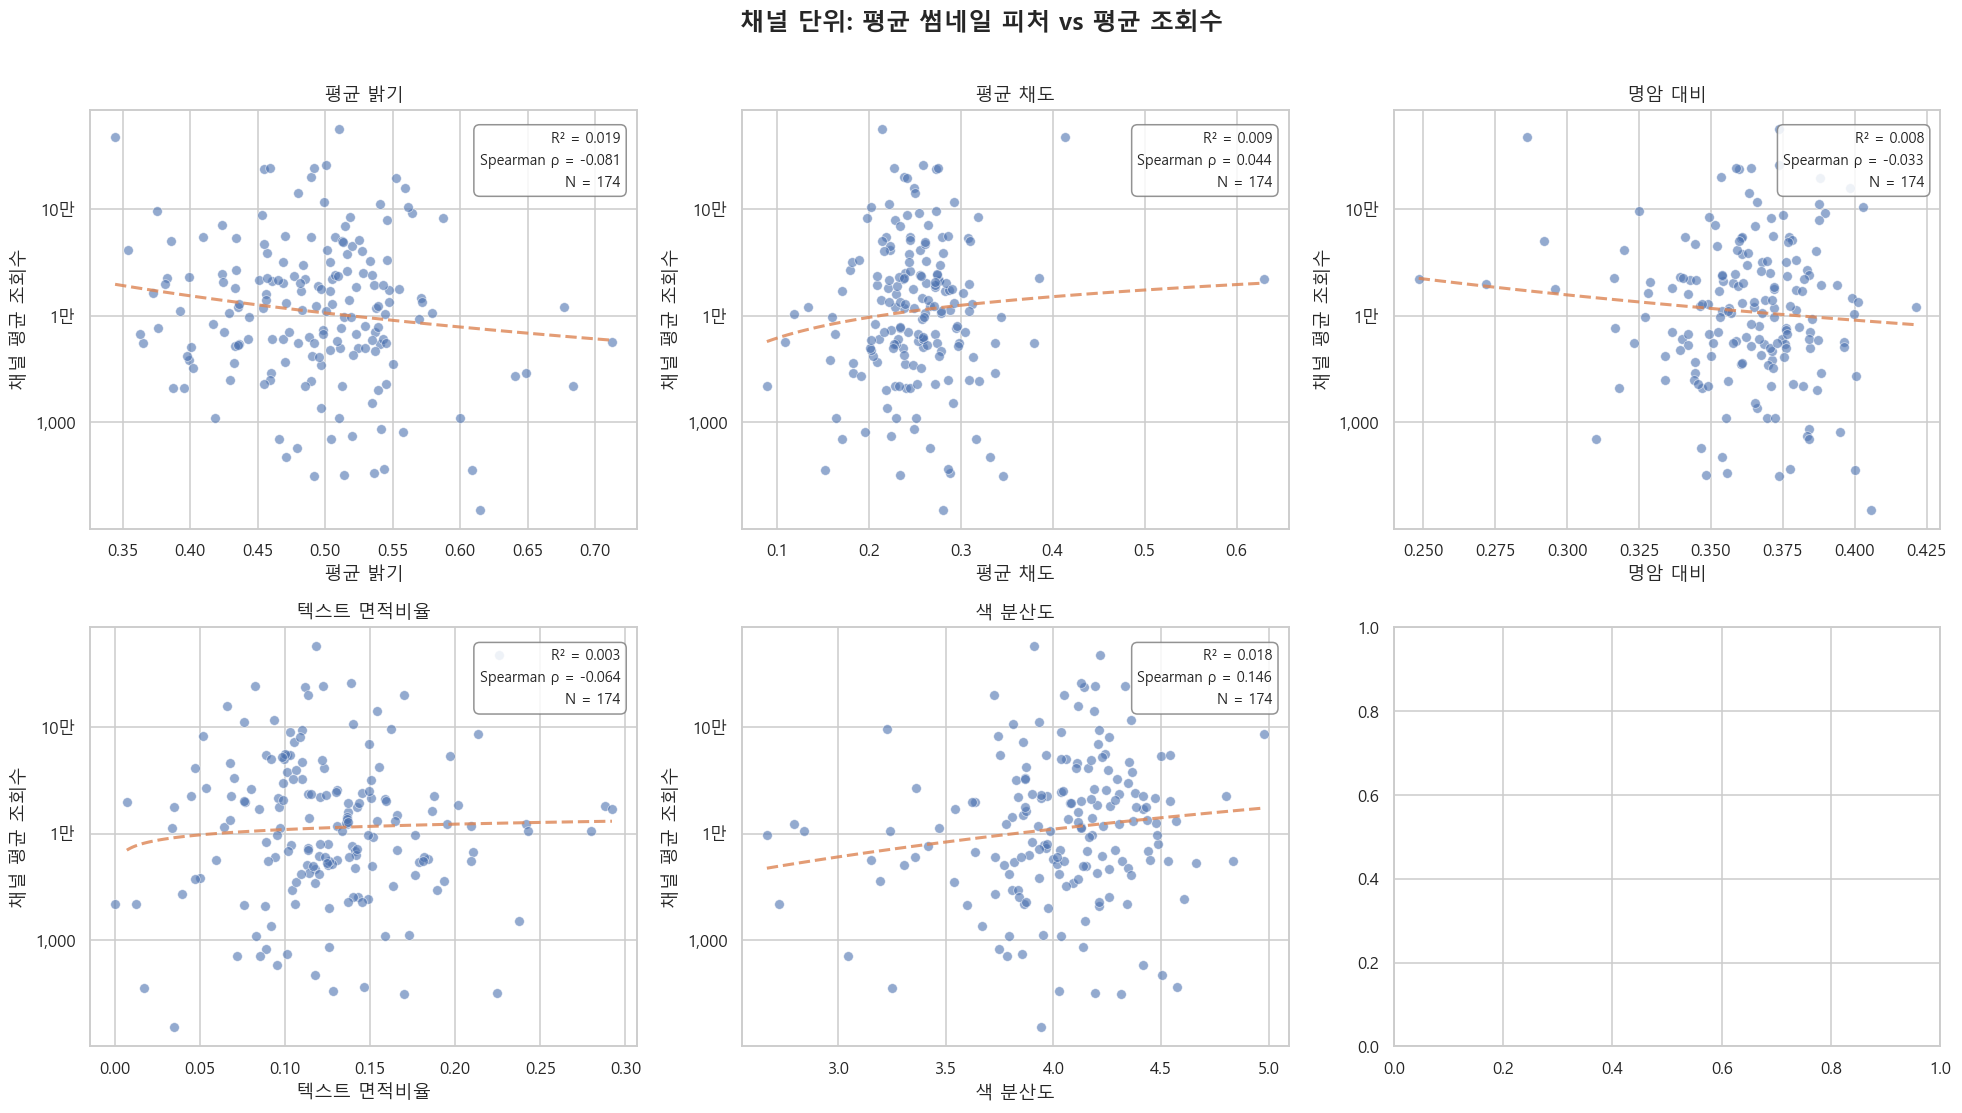


  combo
[썸네일 조합 피처 탐색] 일반 영상 N=9,108


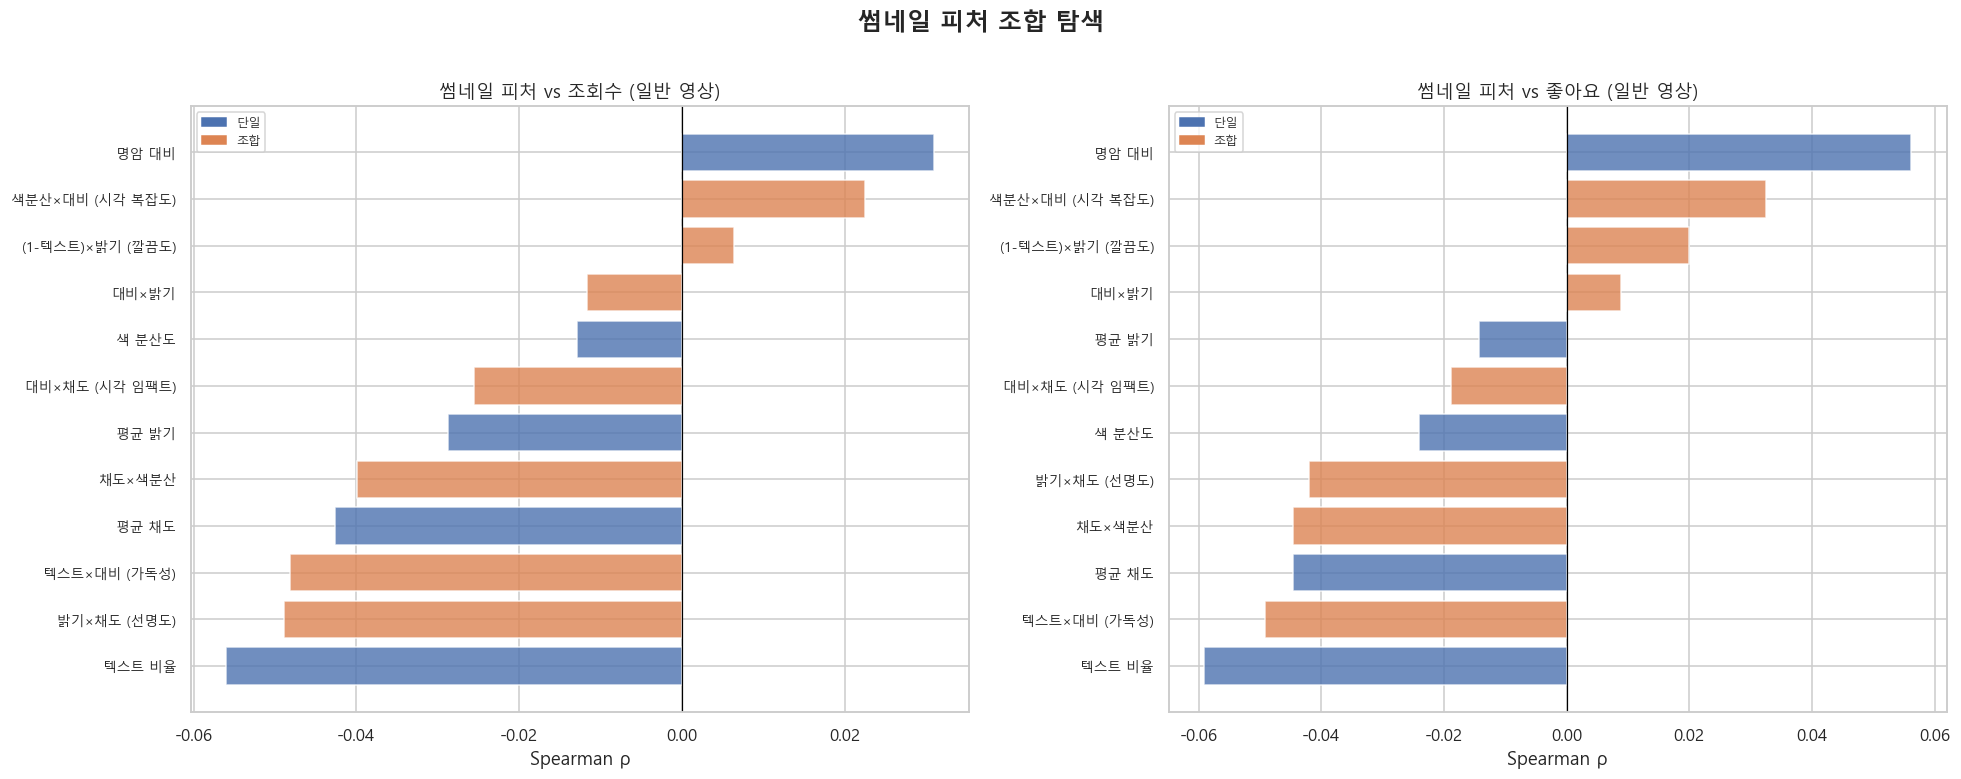

In [32]:
# 전체 실행 또는 섹션 선택
# thumb.run_thumb_eda(df, sections=['overview', 'correlation', 'vs_views'])
thumb.run_thumb_eda(df)

### 2-G. 음성 피처 EDA

In [33]:
# 음성 데이터 로드
VOICE_CSV = DATA_DIR / 'features' / 'voice' / 'channels_voice.csv'
df_va = voice.load_voice_data(df, VOICE_CSV, encoding='cp949')
df_va.head(1)

음성 데이터 병합 완료: 174개 채널


,channel_name,channel_id,file,duration_sec,speech_ratio,speech_sec,silence_sec,num_segments,mean_pause_sec,f0_mean,...,median_view,total_view,subscriber_count,video_count,avg_like,avg_comment,sex,group,channel_title,final_score
0,Onyu Ch. 오뉴,UCpvk50-r2n1FqXaRvEro9lg,input_0001_vocals.wav,404.97068,0.985777,399.21,5.76,25.0,0.2304,141.399903,...,20093.0,4350227,76800,164,1469.219512,48.25,남자,[RE:Revolution],Onyu Ch. 오뉴,21.978488



  overview
[음성 데이터] shape: (174, 32)


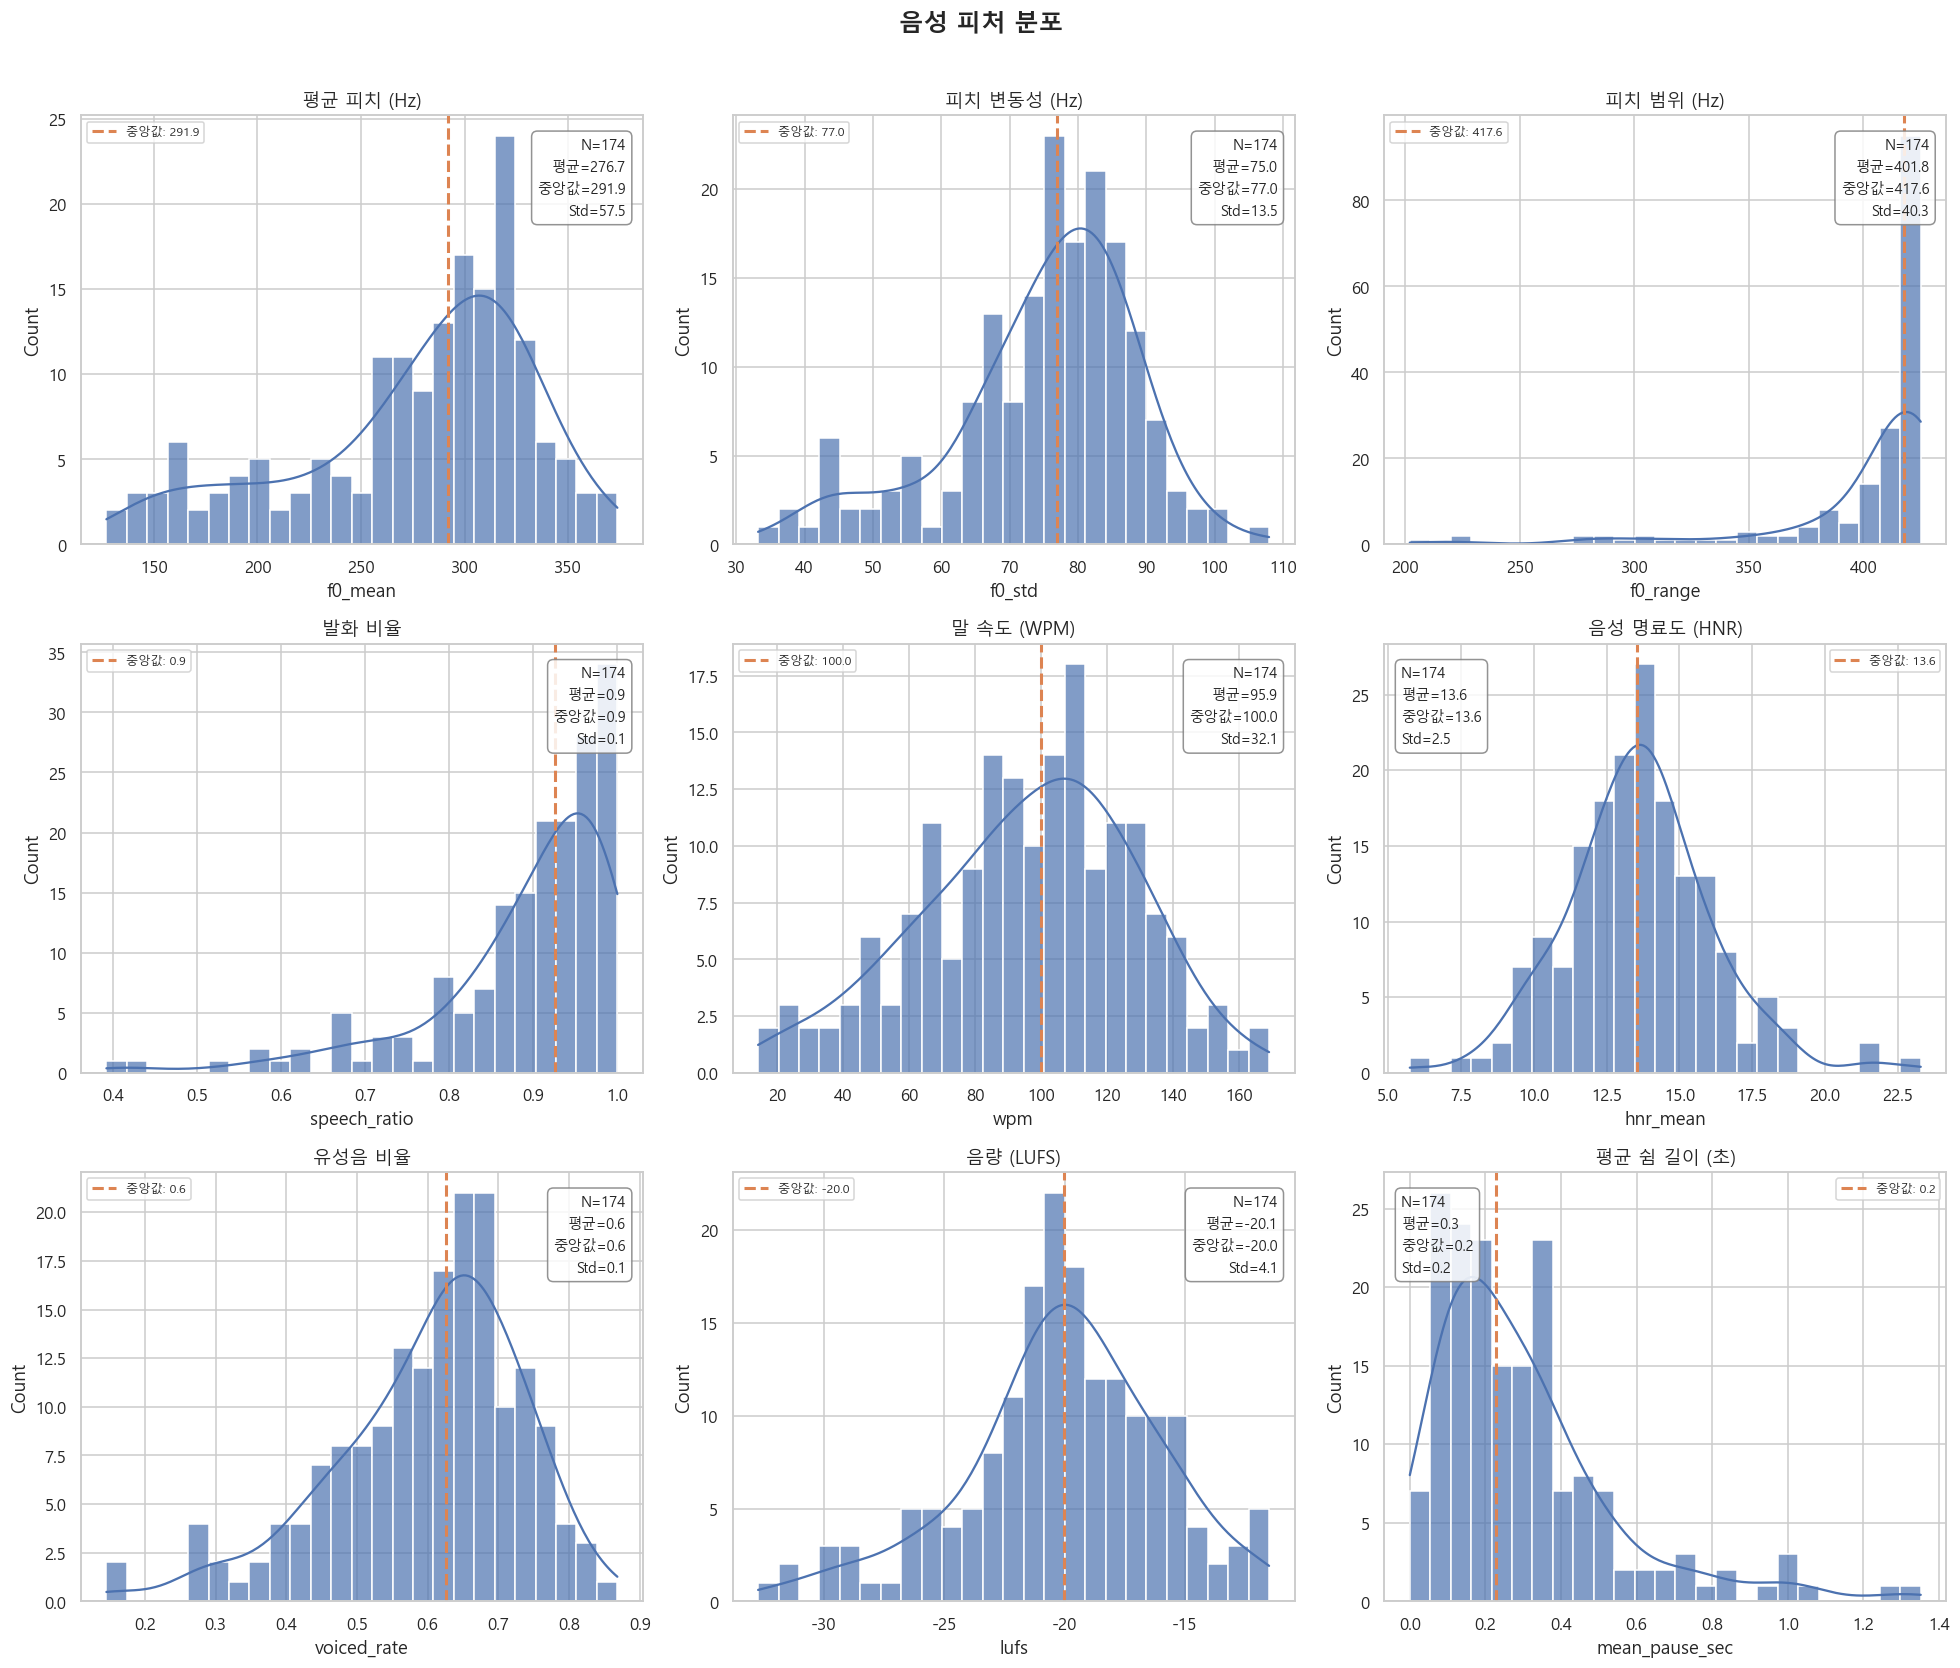


  correlation


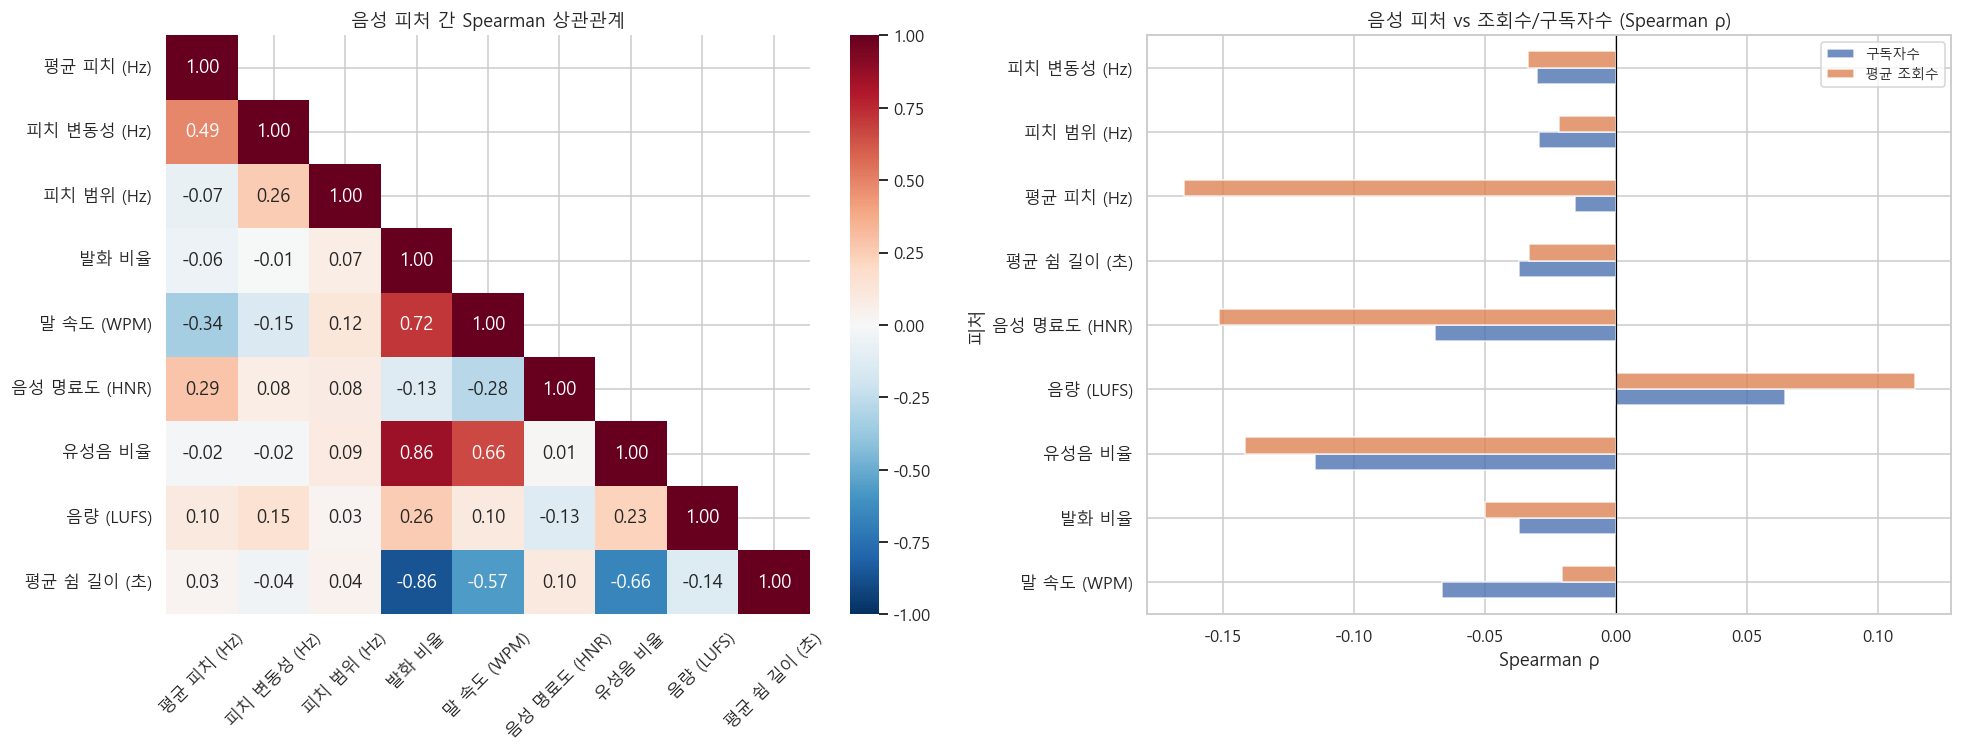


  vs_views


D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_voice.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=9)


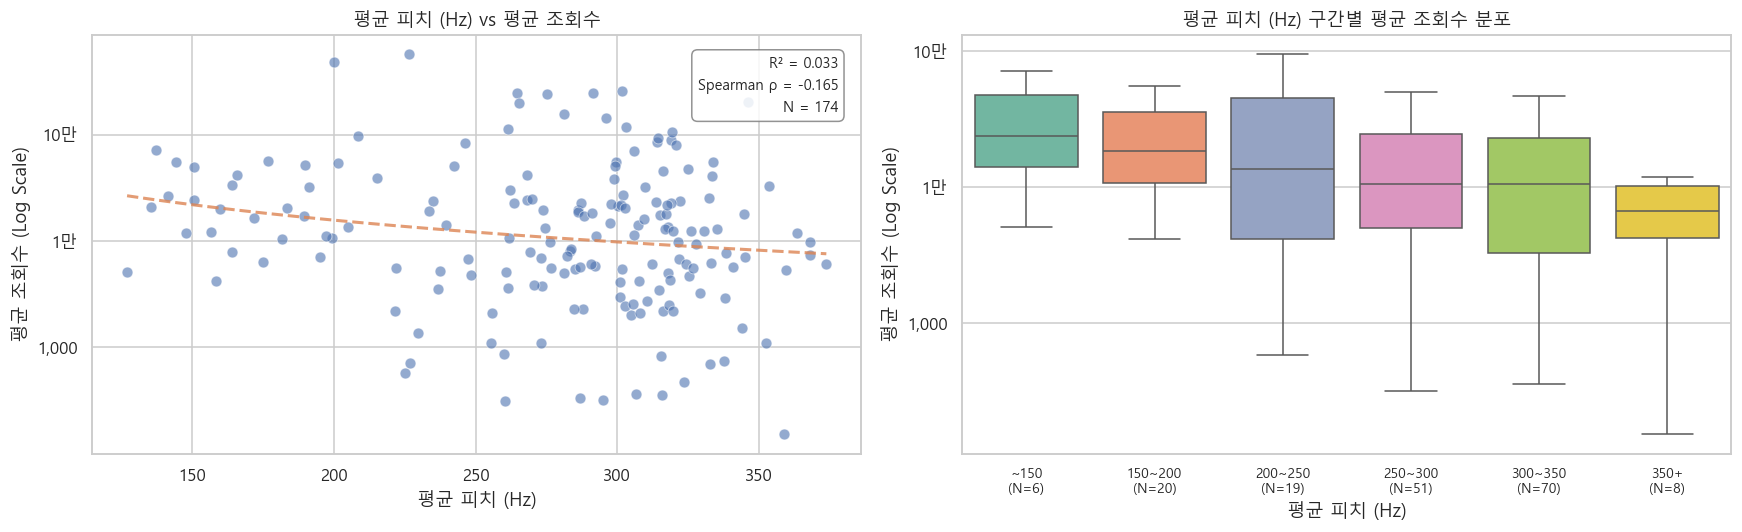

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_voice.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=9)


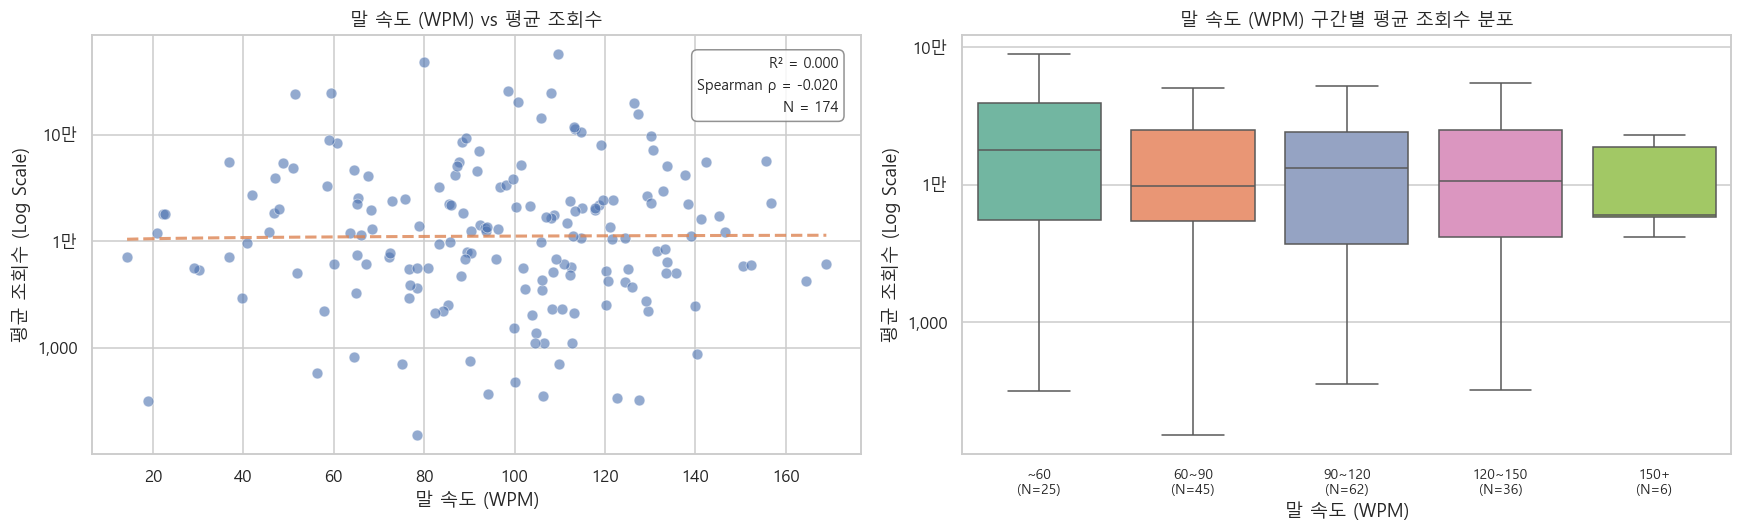

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_voice.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=9)


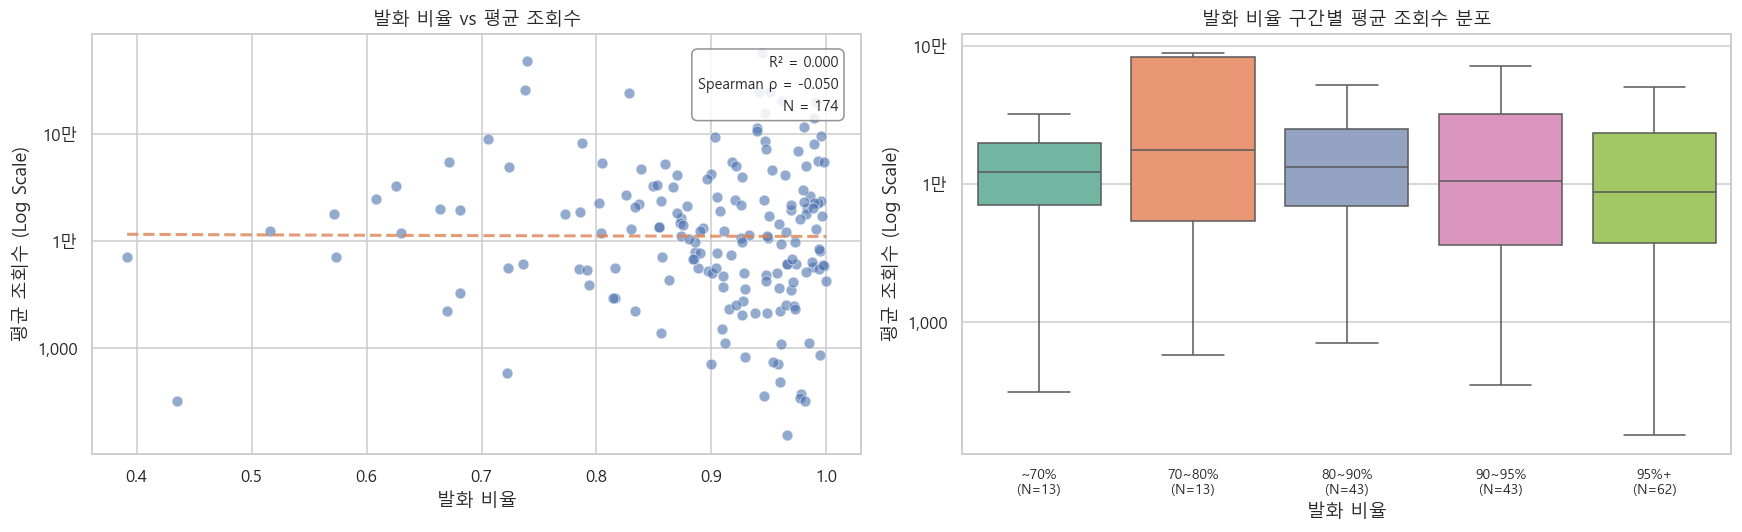

D:\SK-Planet\머신러닝 프로젝트\vtuber-view-forecast\notebooks\01_EDA\modules\eda_voice.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, fontsize=9)


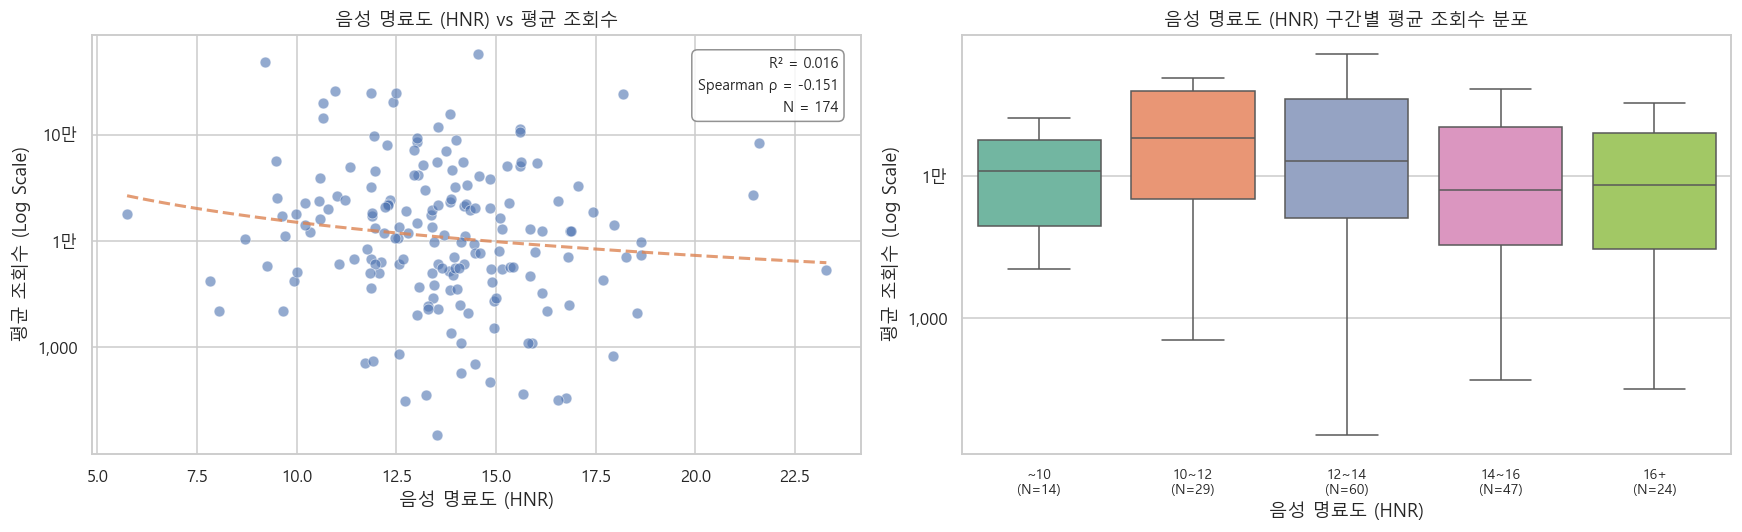


  gender_group


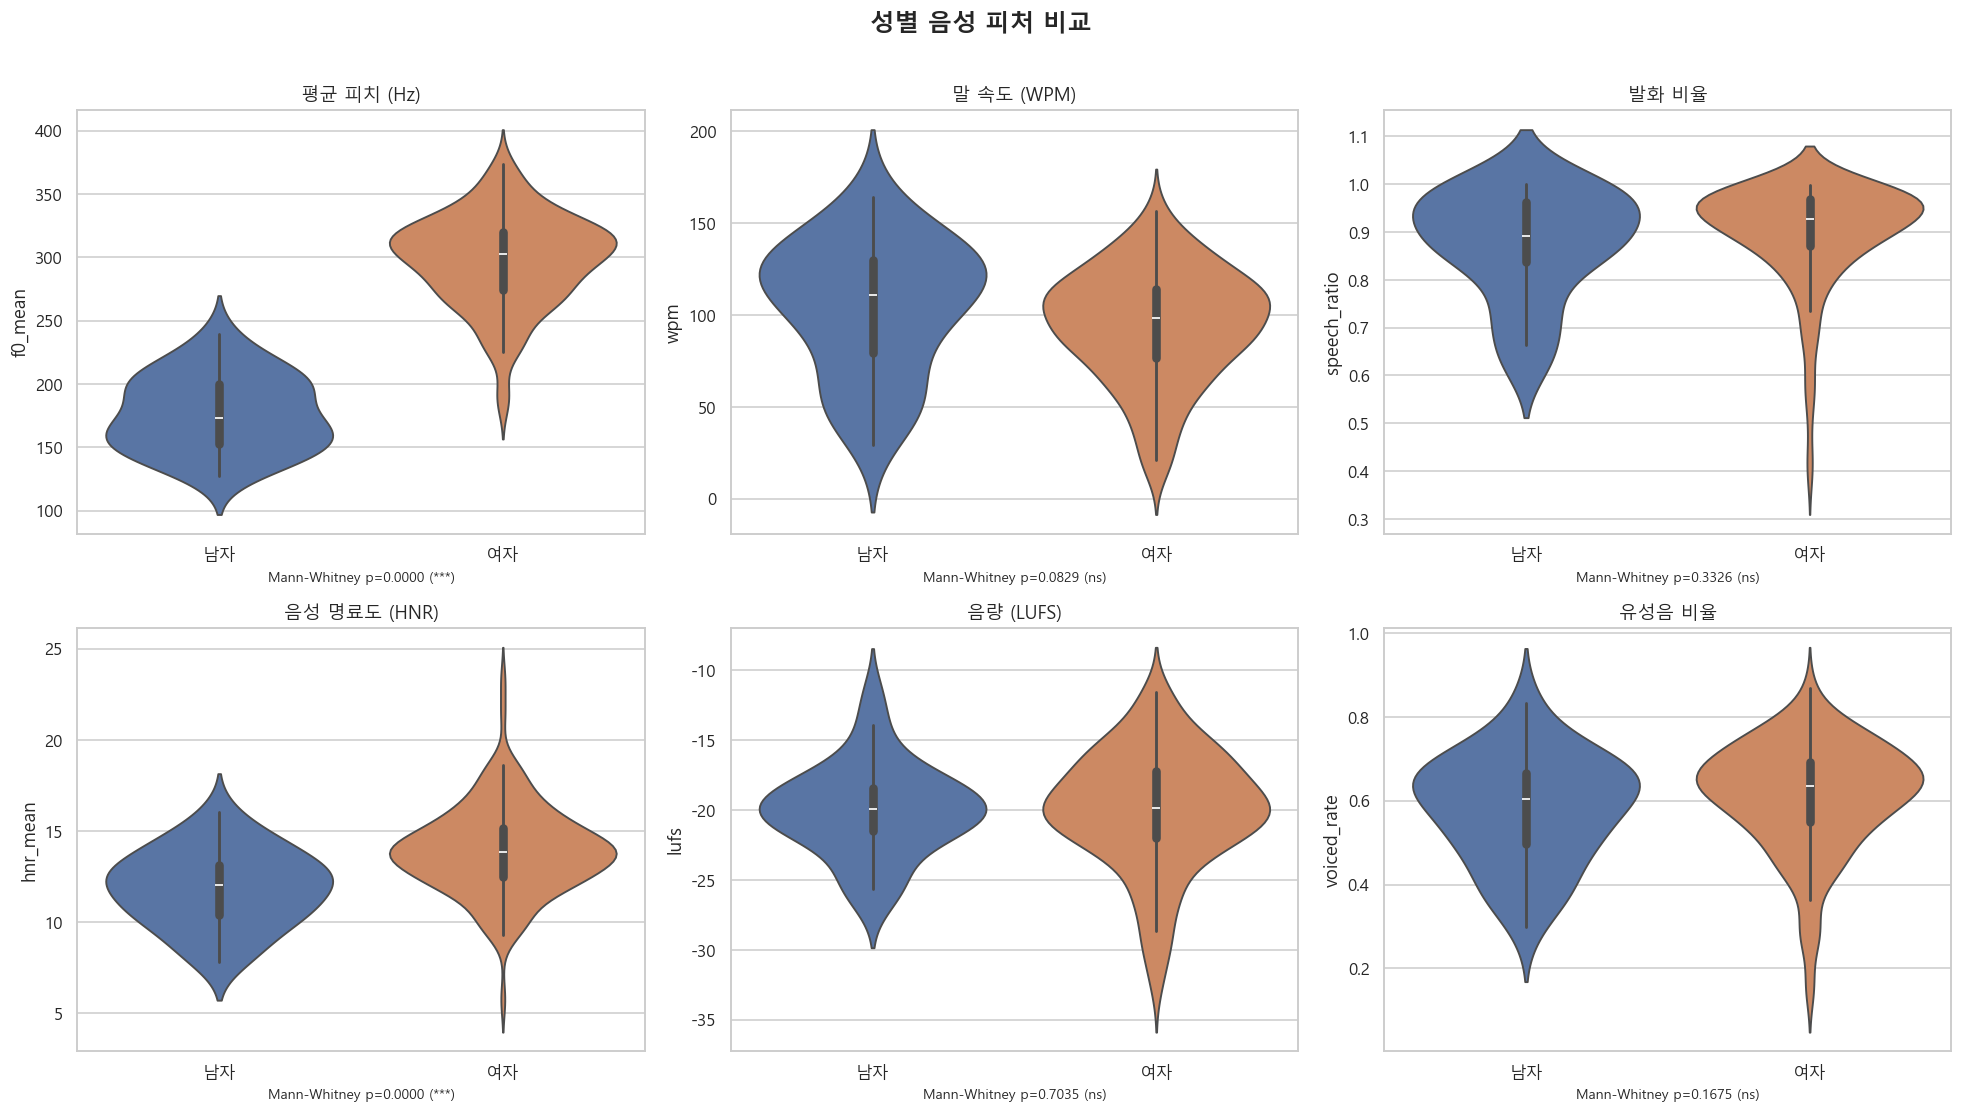

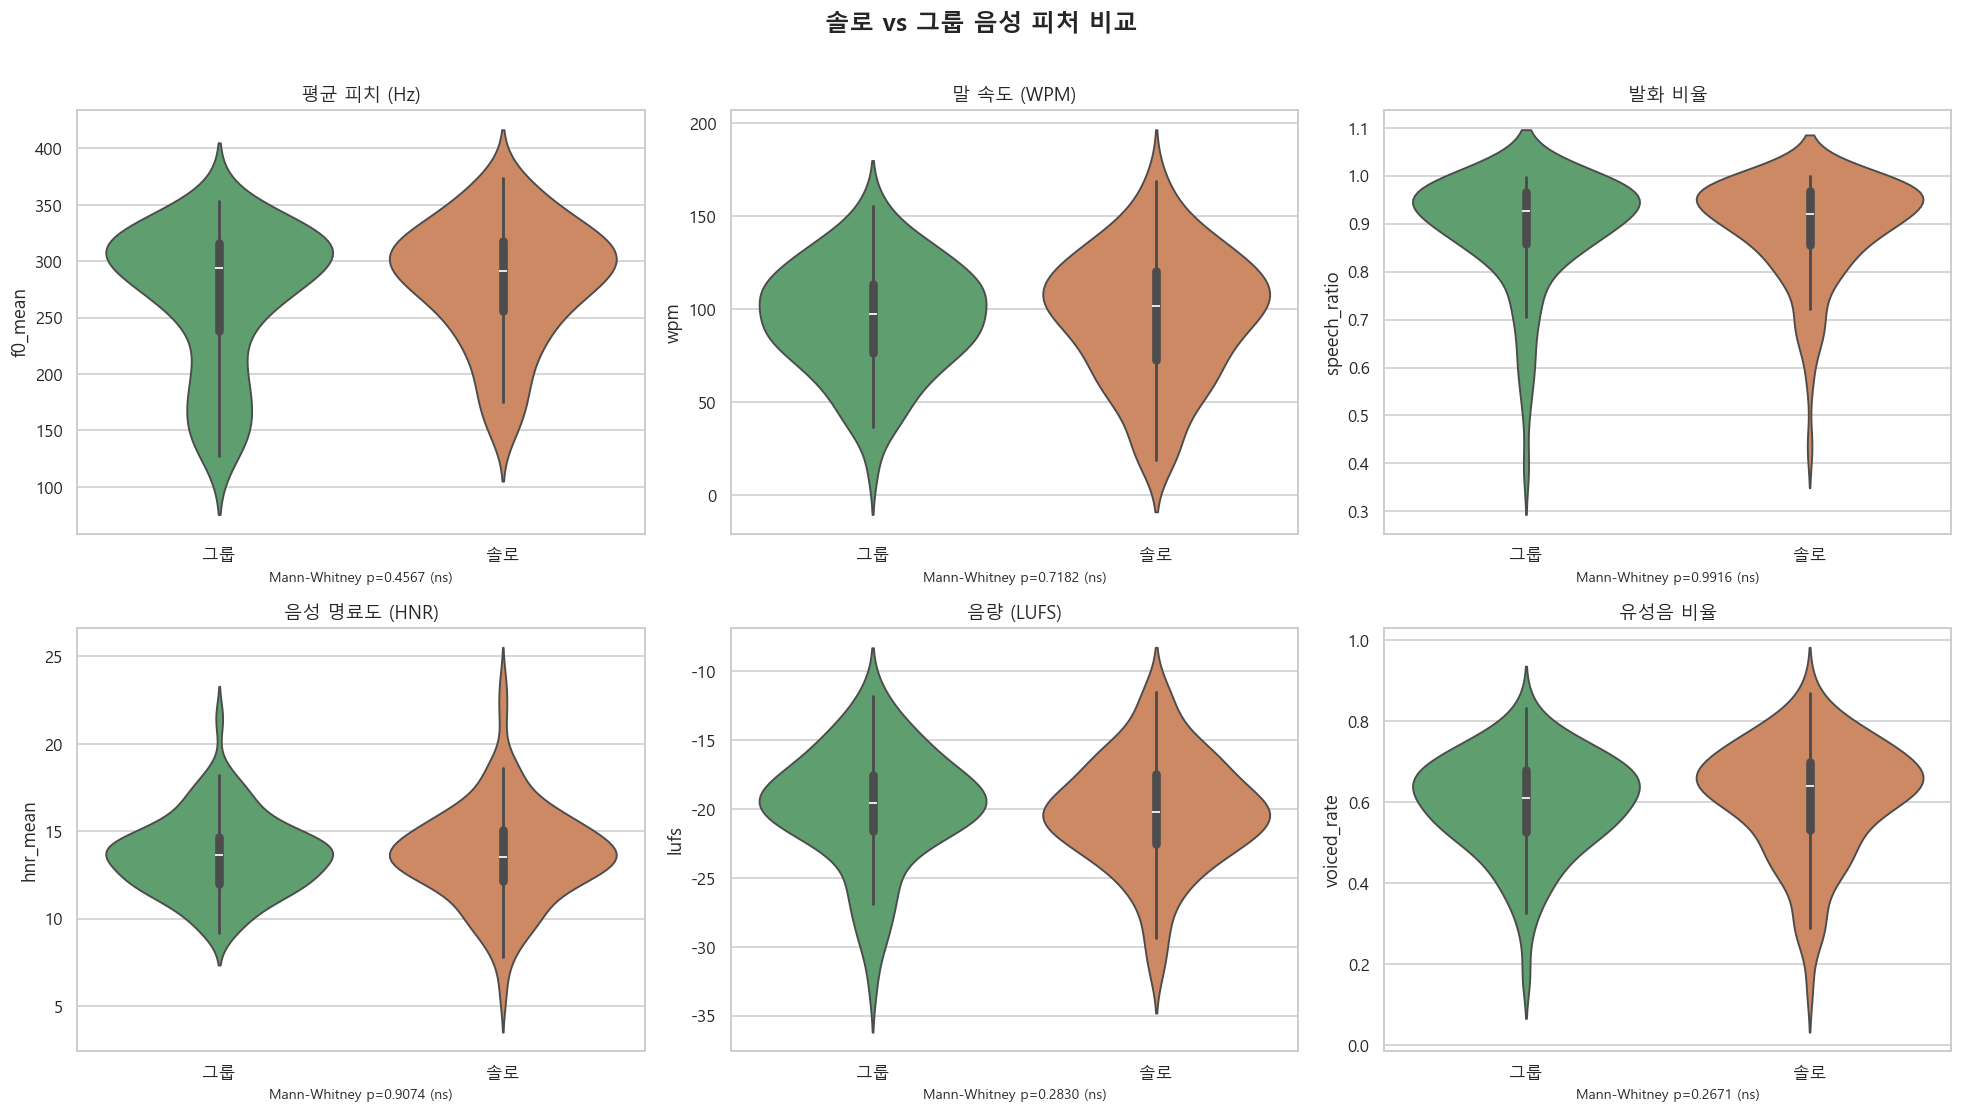


  gender_channel


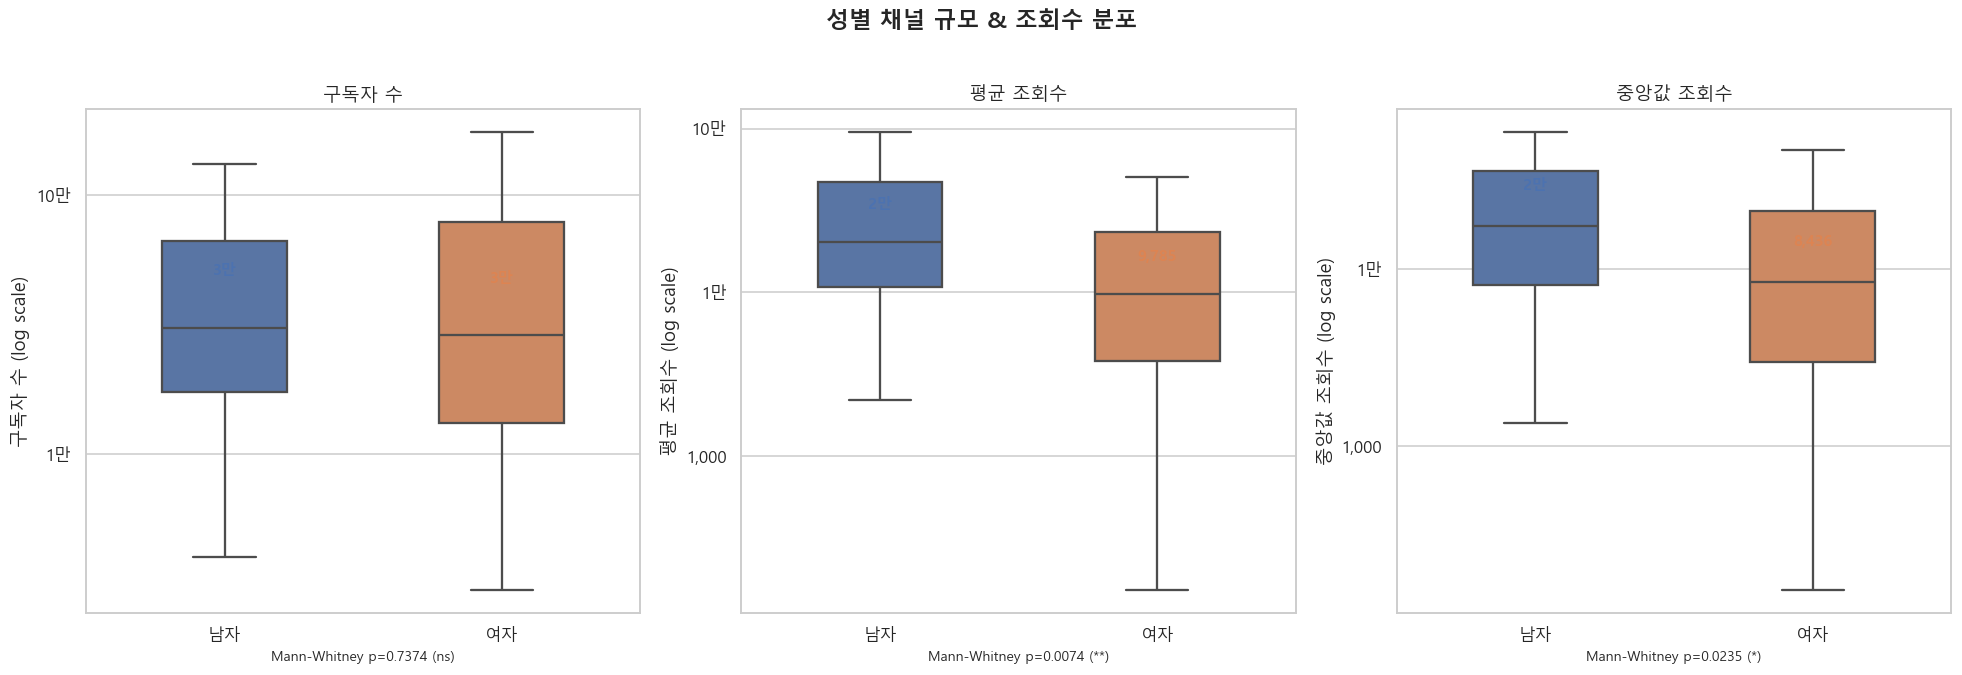

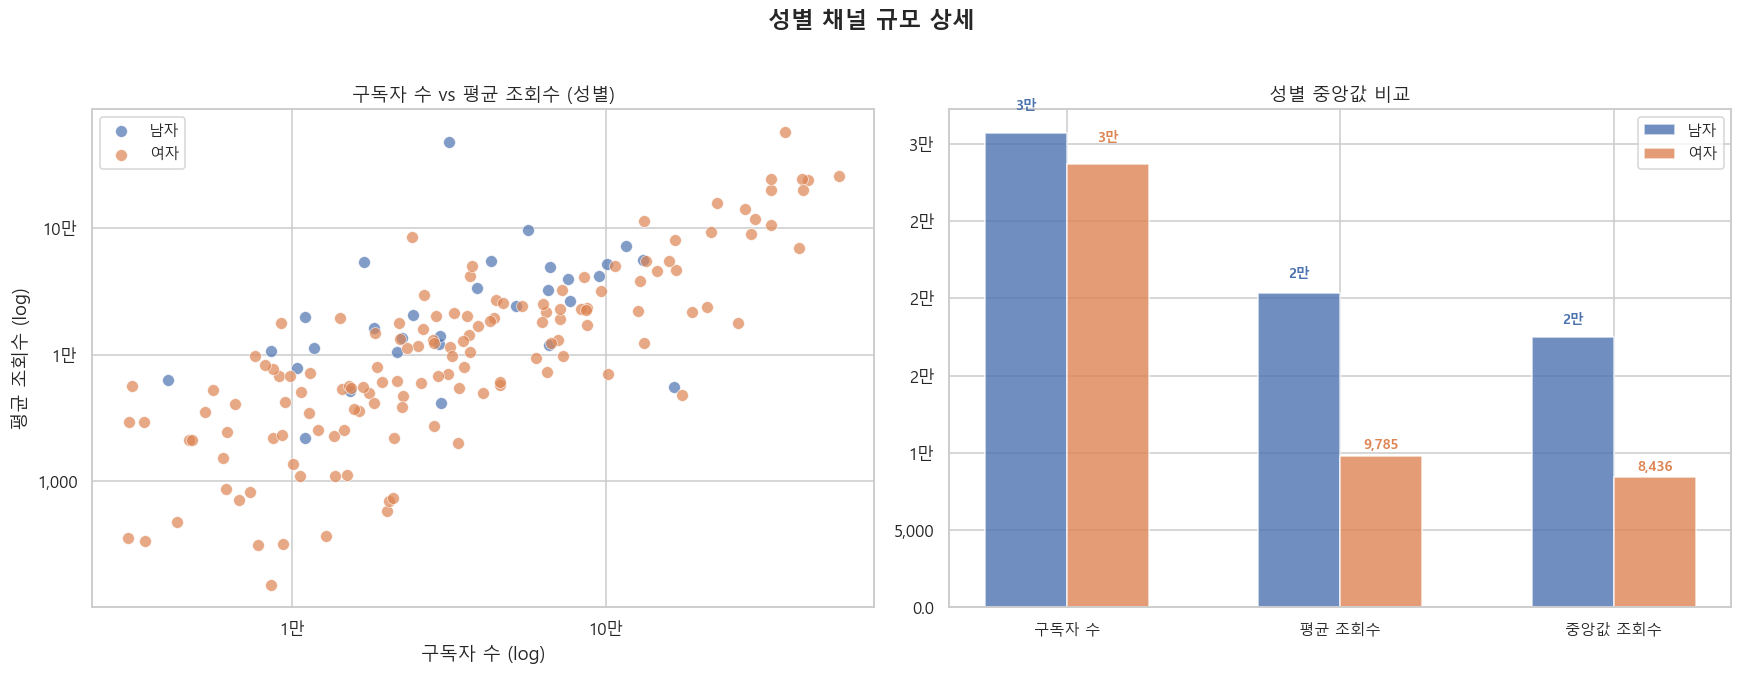


[성별 채널 규모 요약]
     채널수  구독자수_중앙값     평균조회수_중앙값  중앙값조회수_중앙값
sex                                         
남자    30   30700.0  20320.272059     17478.5
여자   139   28700.0   9784.888889      8436.0

  gender_control


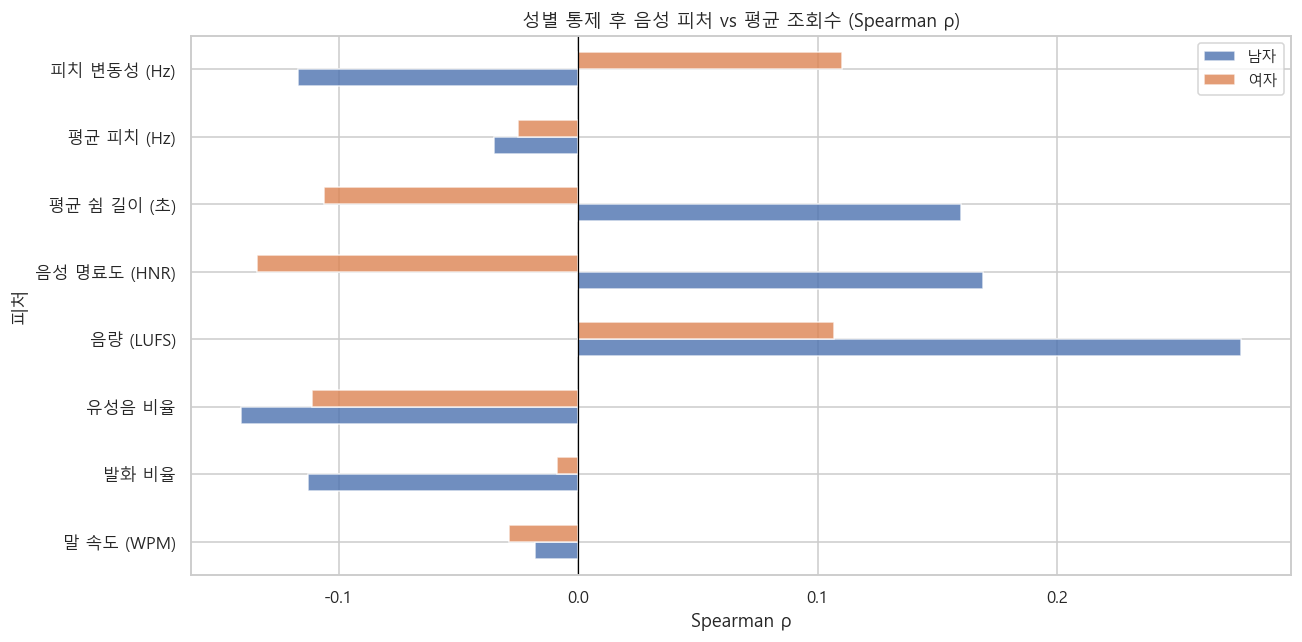


  engagement


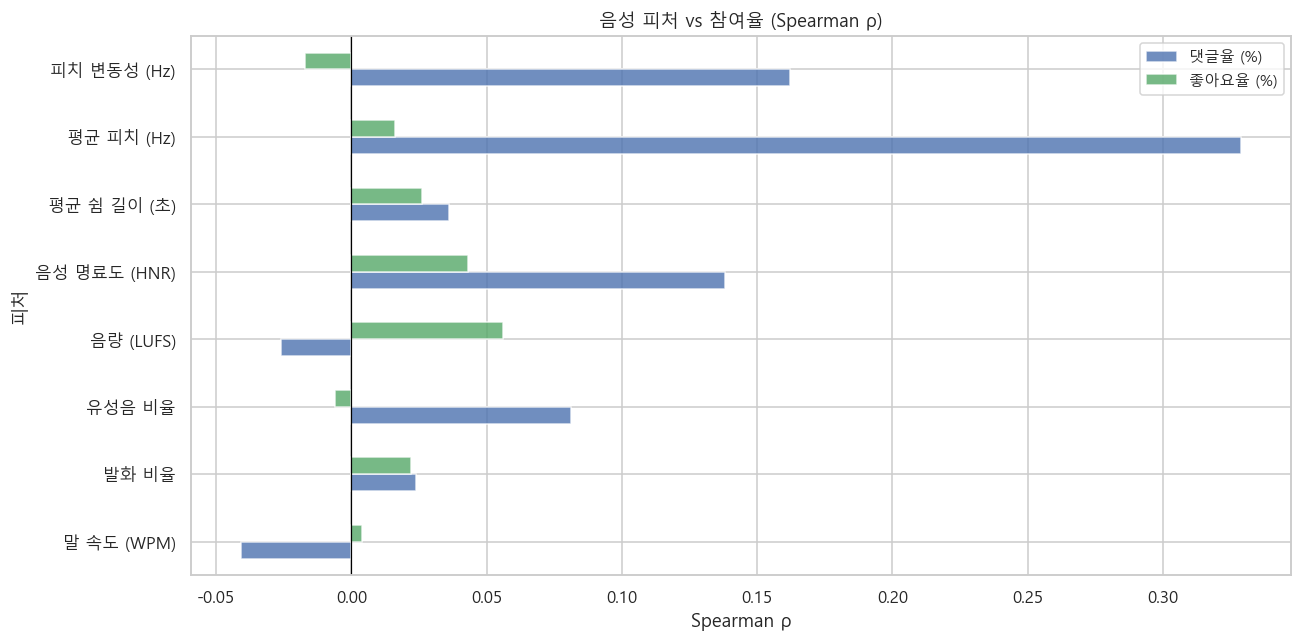


[유의한 상관 2건 — 개별 산점도]


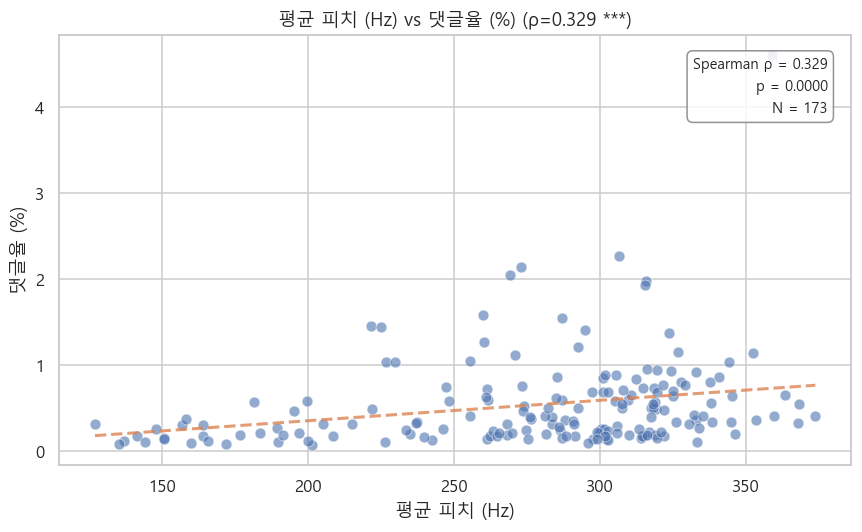

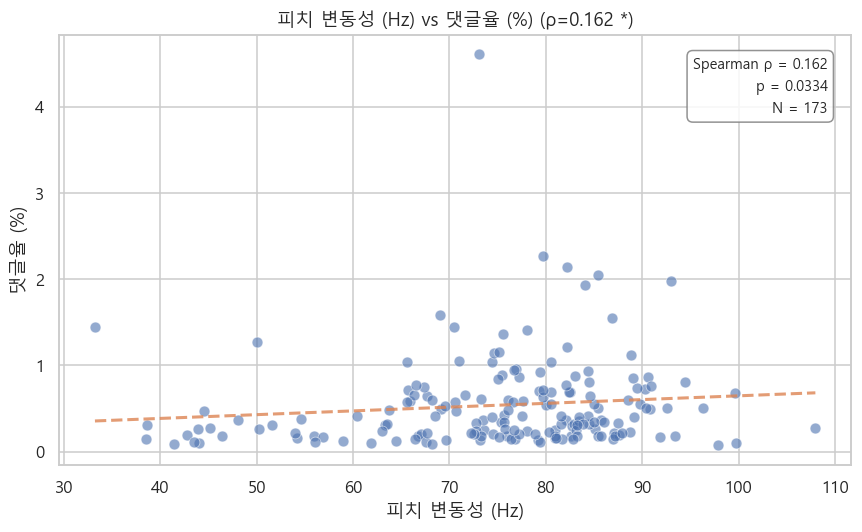


  appearance


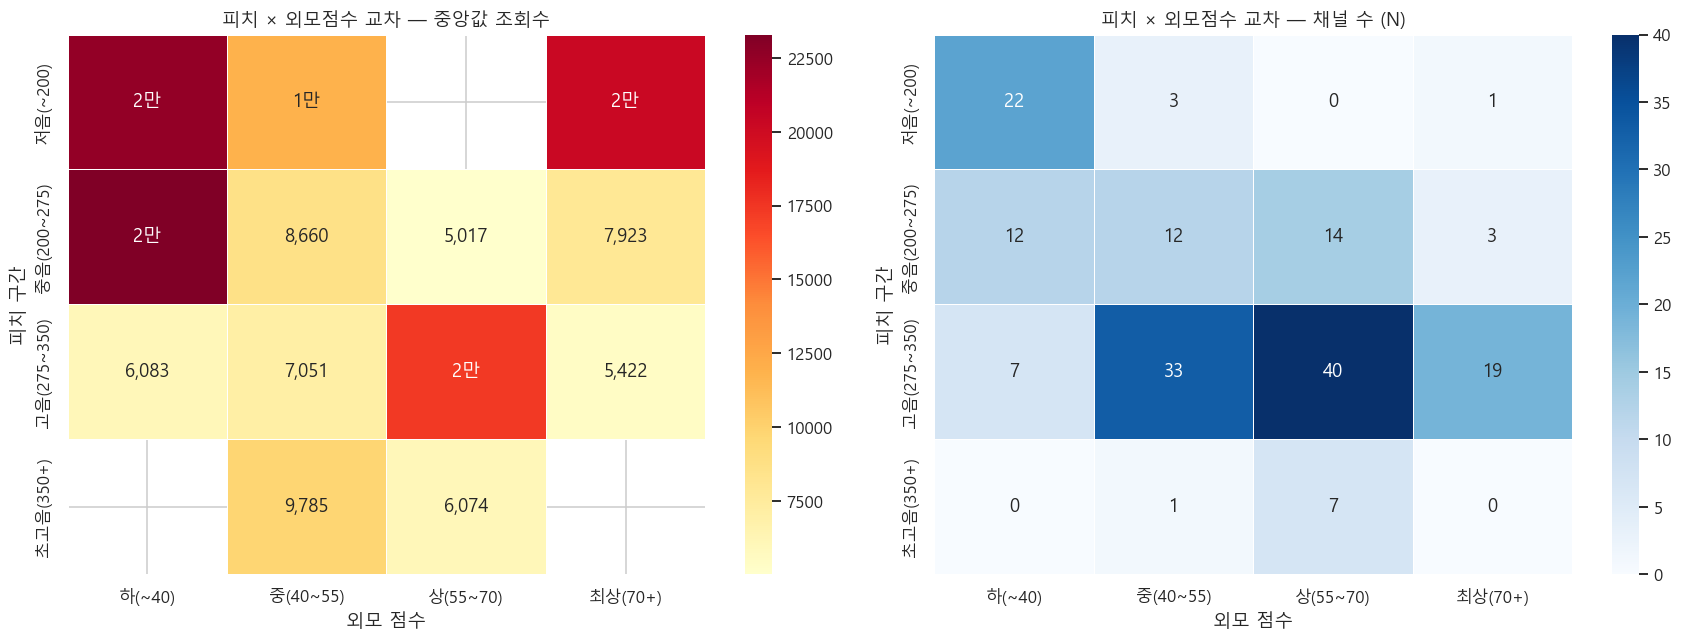

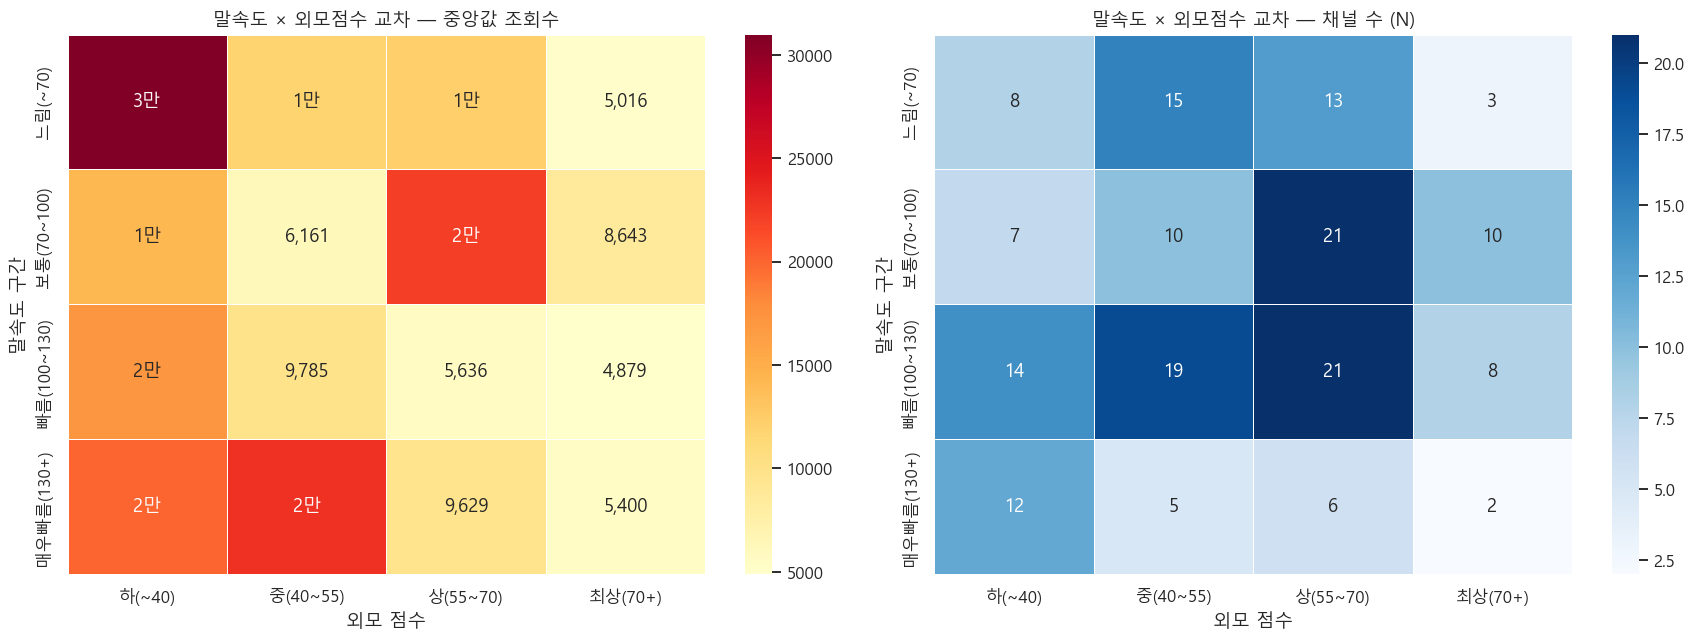


  combo
[음성 조합 피처 탐색] N=174


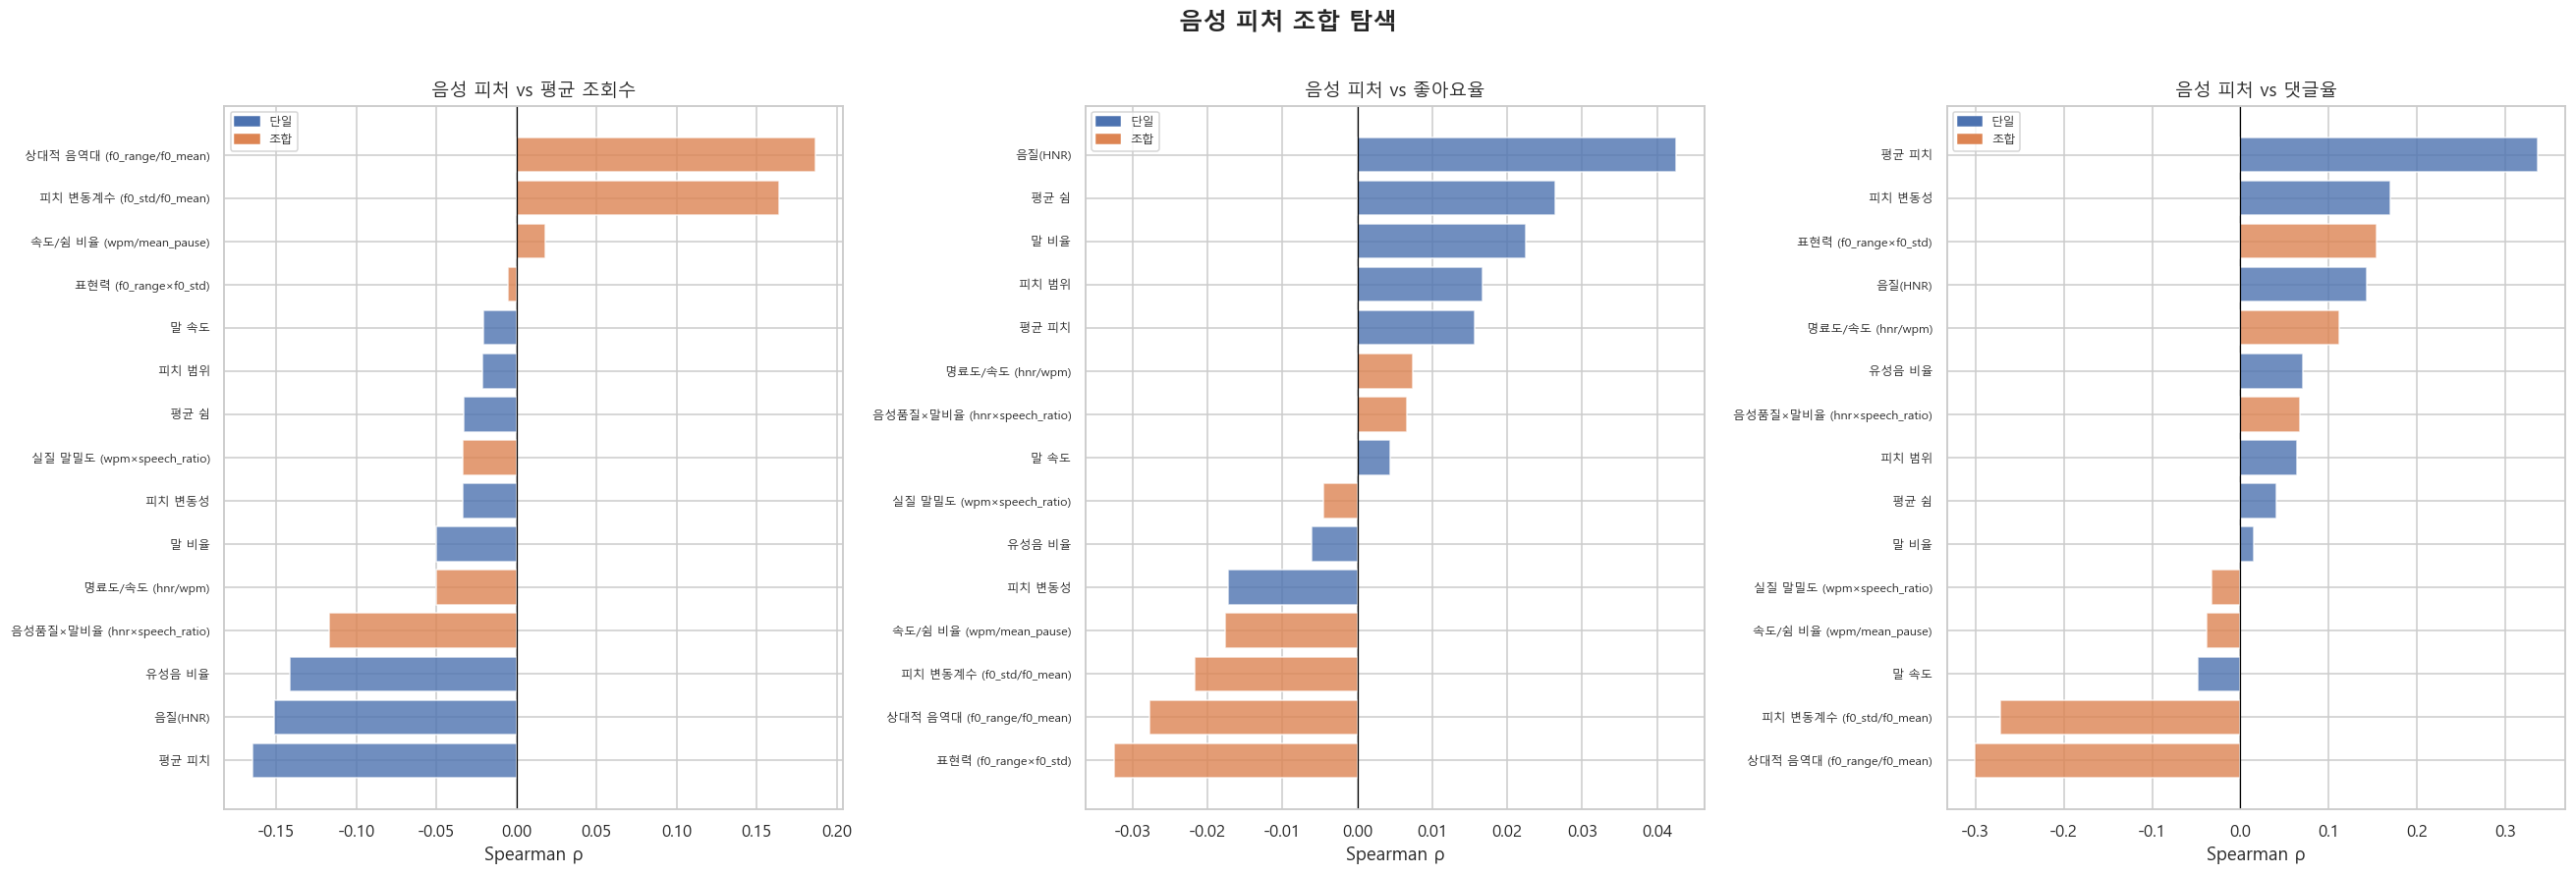

In [34]:
# 전체 실행 또는 섹션 선택
# voice.run_voice_eda(df_va, sections=['overview', 'correlation', 'vs_views'])
voice.run_voice_eda(df_va)

## 3. 모델 결과 EDA

In [35]:
# train/test 로드 + FE
SPLIT_DIR = DATA_DIR / 'splits'
train = pd.read_csv(SPLIT_DIR / 'train.csv', sep='\x01')
test  = pd.read_csv(SPLIT_DIR / 'test.csv',  sep='\x01')

train = fe.run_feature_engineering(train)
test  = fe.run_feature_engineering(test)

jnn_target_cols, jnn_agg_func_names = fe.get_jnn_params()
train = make_jnn_features(train, N=10, drop_insufficient=True,
                          target_cols=jnn_target_cols, agg_funcs=jnn_agg_func_names)
test = fe.map_channel_features(train, test)
test = fe.map_jnn_features(train, test)
test = fe.map_video_order(train, test)

# subscriber_count 보존 (select_columns에서 제거됨)
train_sub = train[['video_id', 'subscriber_count']].copy()
test_sub  = test[['video_id', 'subscriber_count']].copy()

train = fe.select_columns(train)
test  = fe.select_columns(test)
train, test = fe.bin_channel_features(train, test, q=10)

# subscriber_count 재합류
train = train.merge(train_sub, on='video_id', how='left')
test  = test.merge(test_sub,  on='video_id', how='left')

print(f'Train: {train.shape} | Test: {test.shape}')

[map_jnn_features] train에 없는 채널 30행 제거 (865 → 835)
Train: (2414, 17) | Test: (835, 17)



[TRAIN] 수치형 7개 · 범주형 6개
Spearman r 해석: |r|≥0.2 강함 / 0.1~0.2 약함 / <0.1 매우 약함


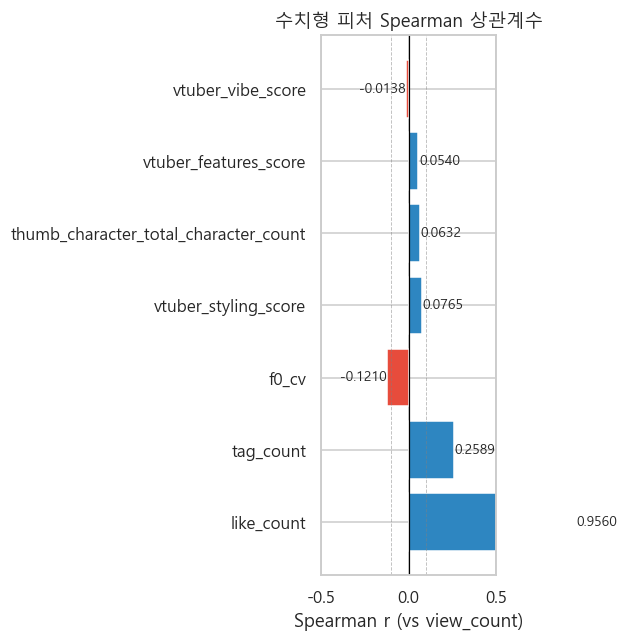

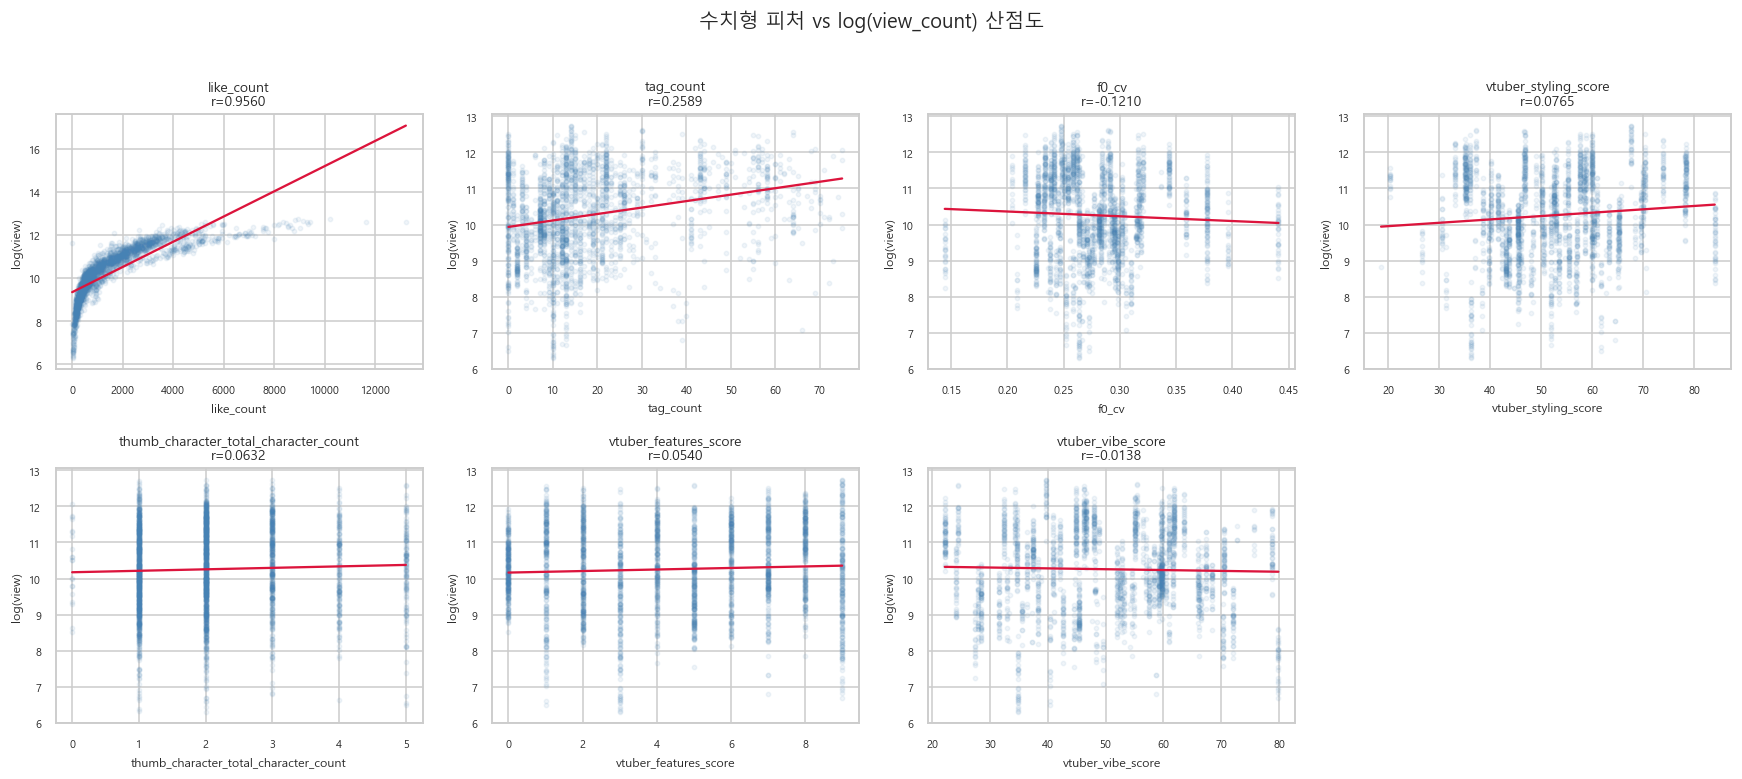

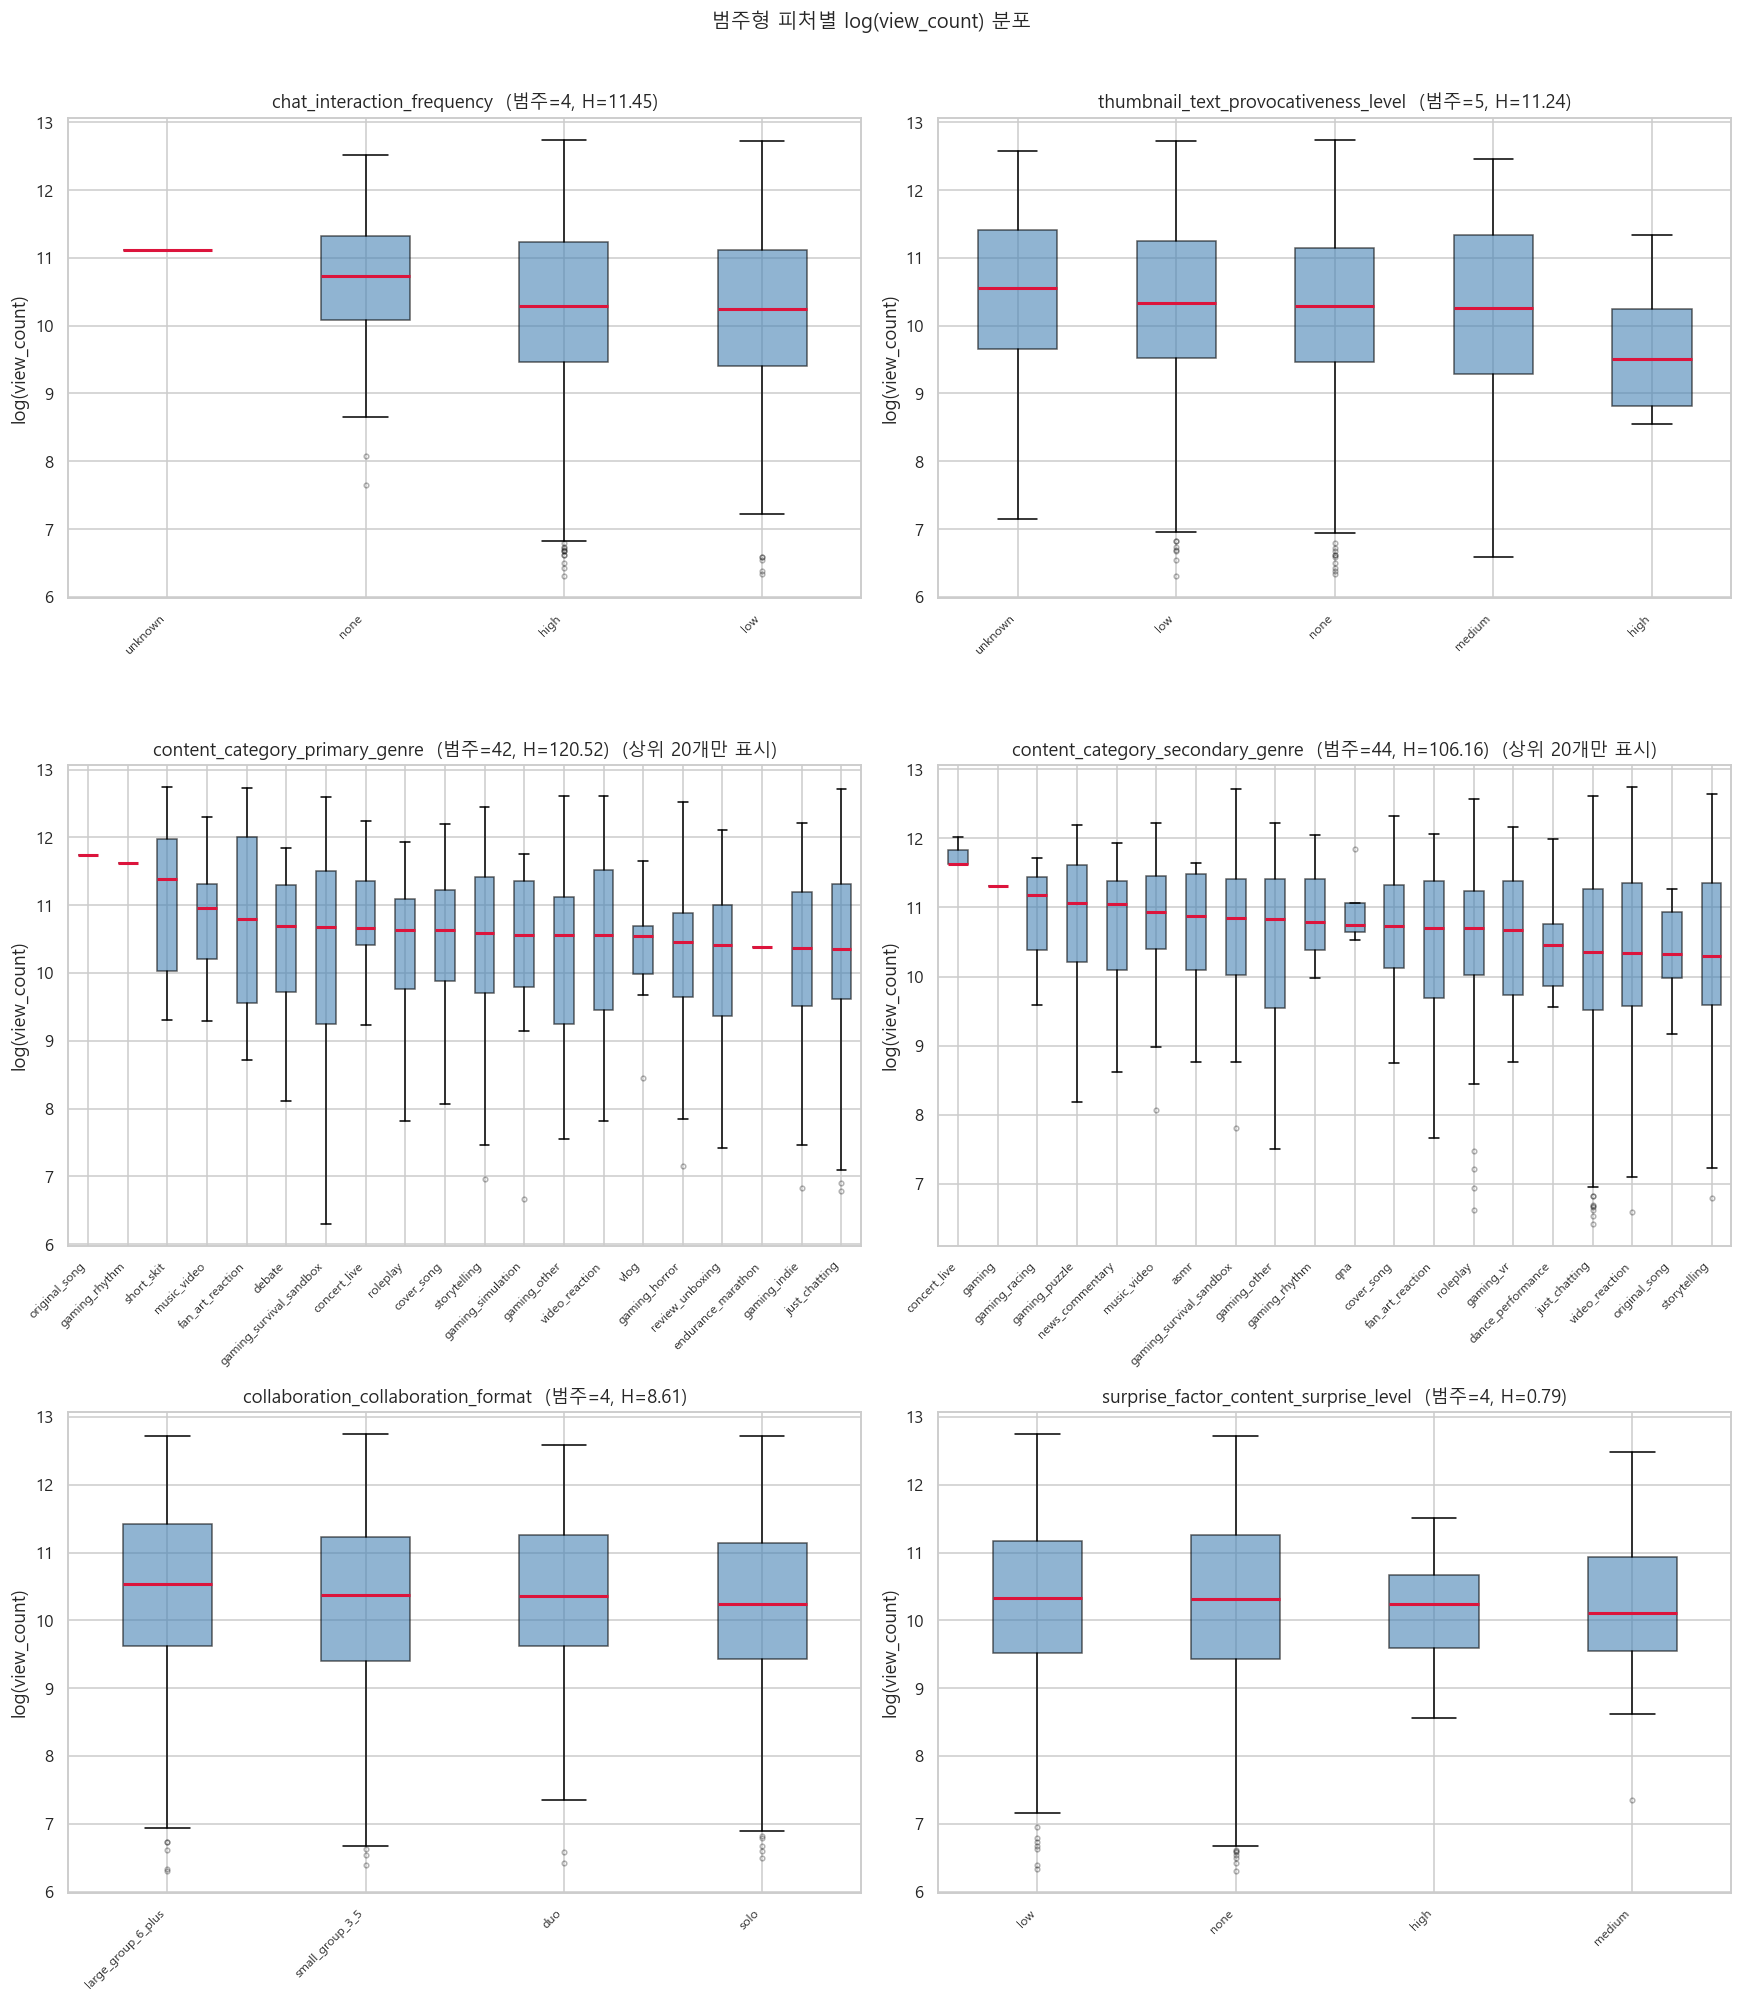


[TEST] 수치형 7개 · 범주형 6개
Spearman r 해석: |r|≥0.2 강함 / 0.1~0.2 약함 / <0.1 매우 약함


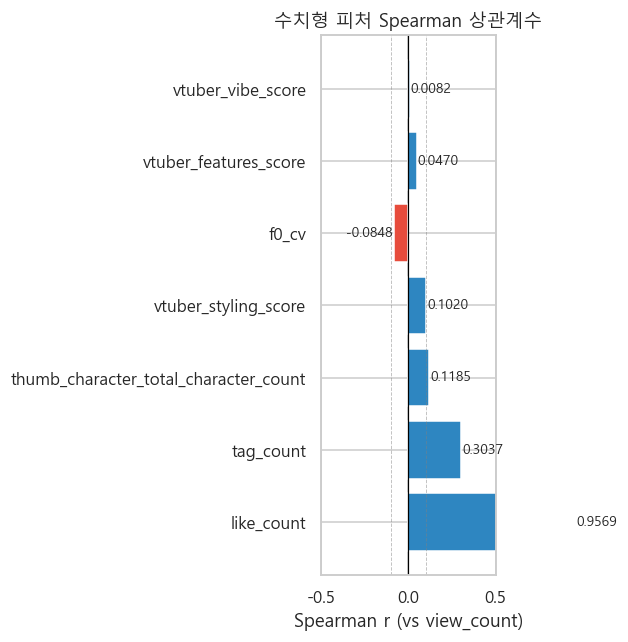

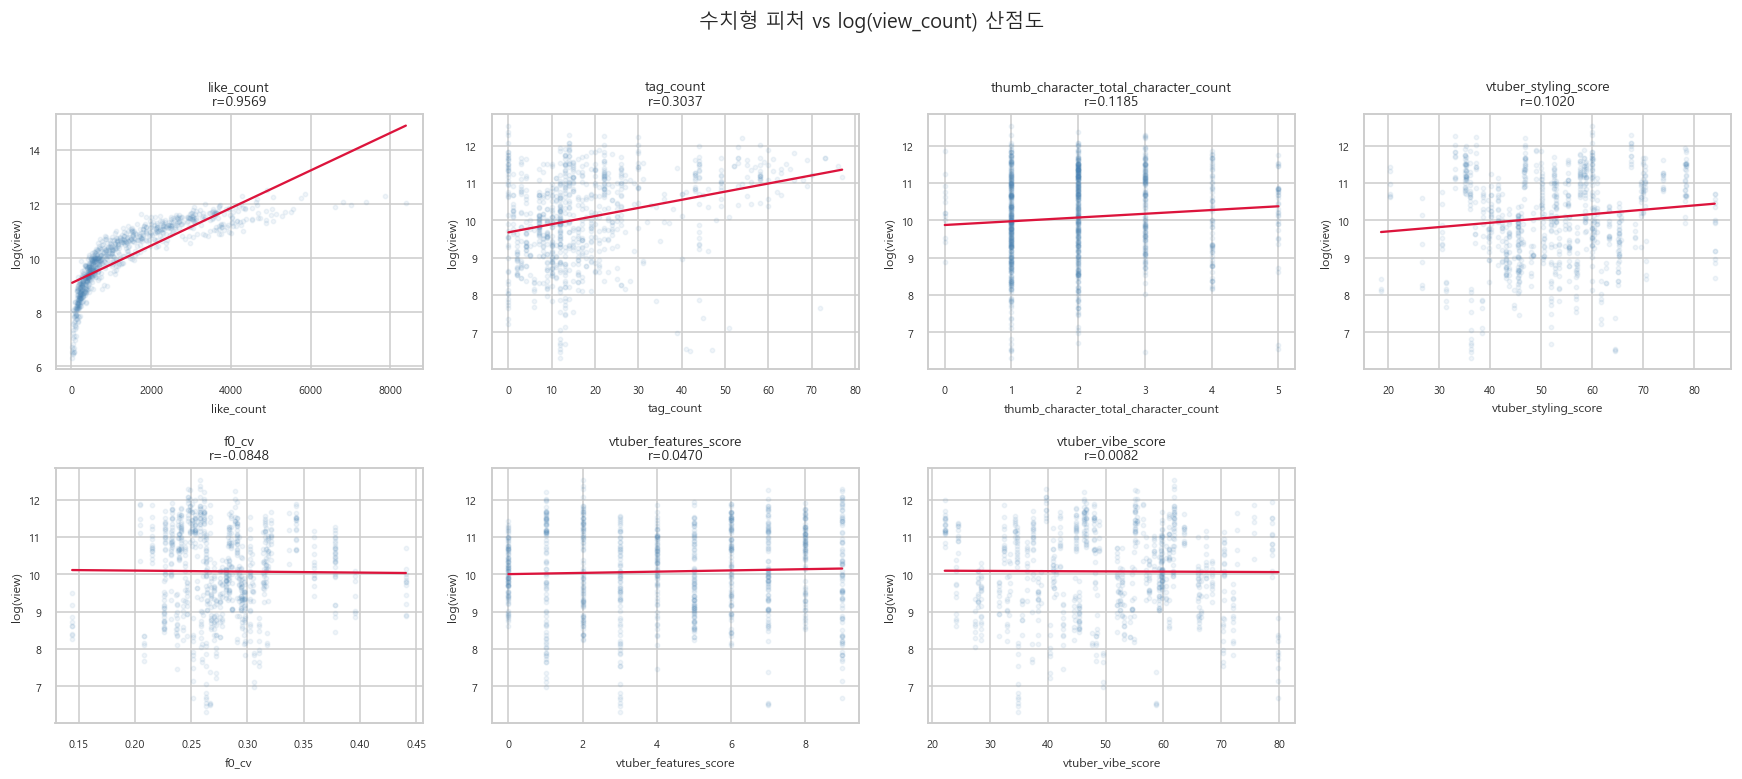

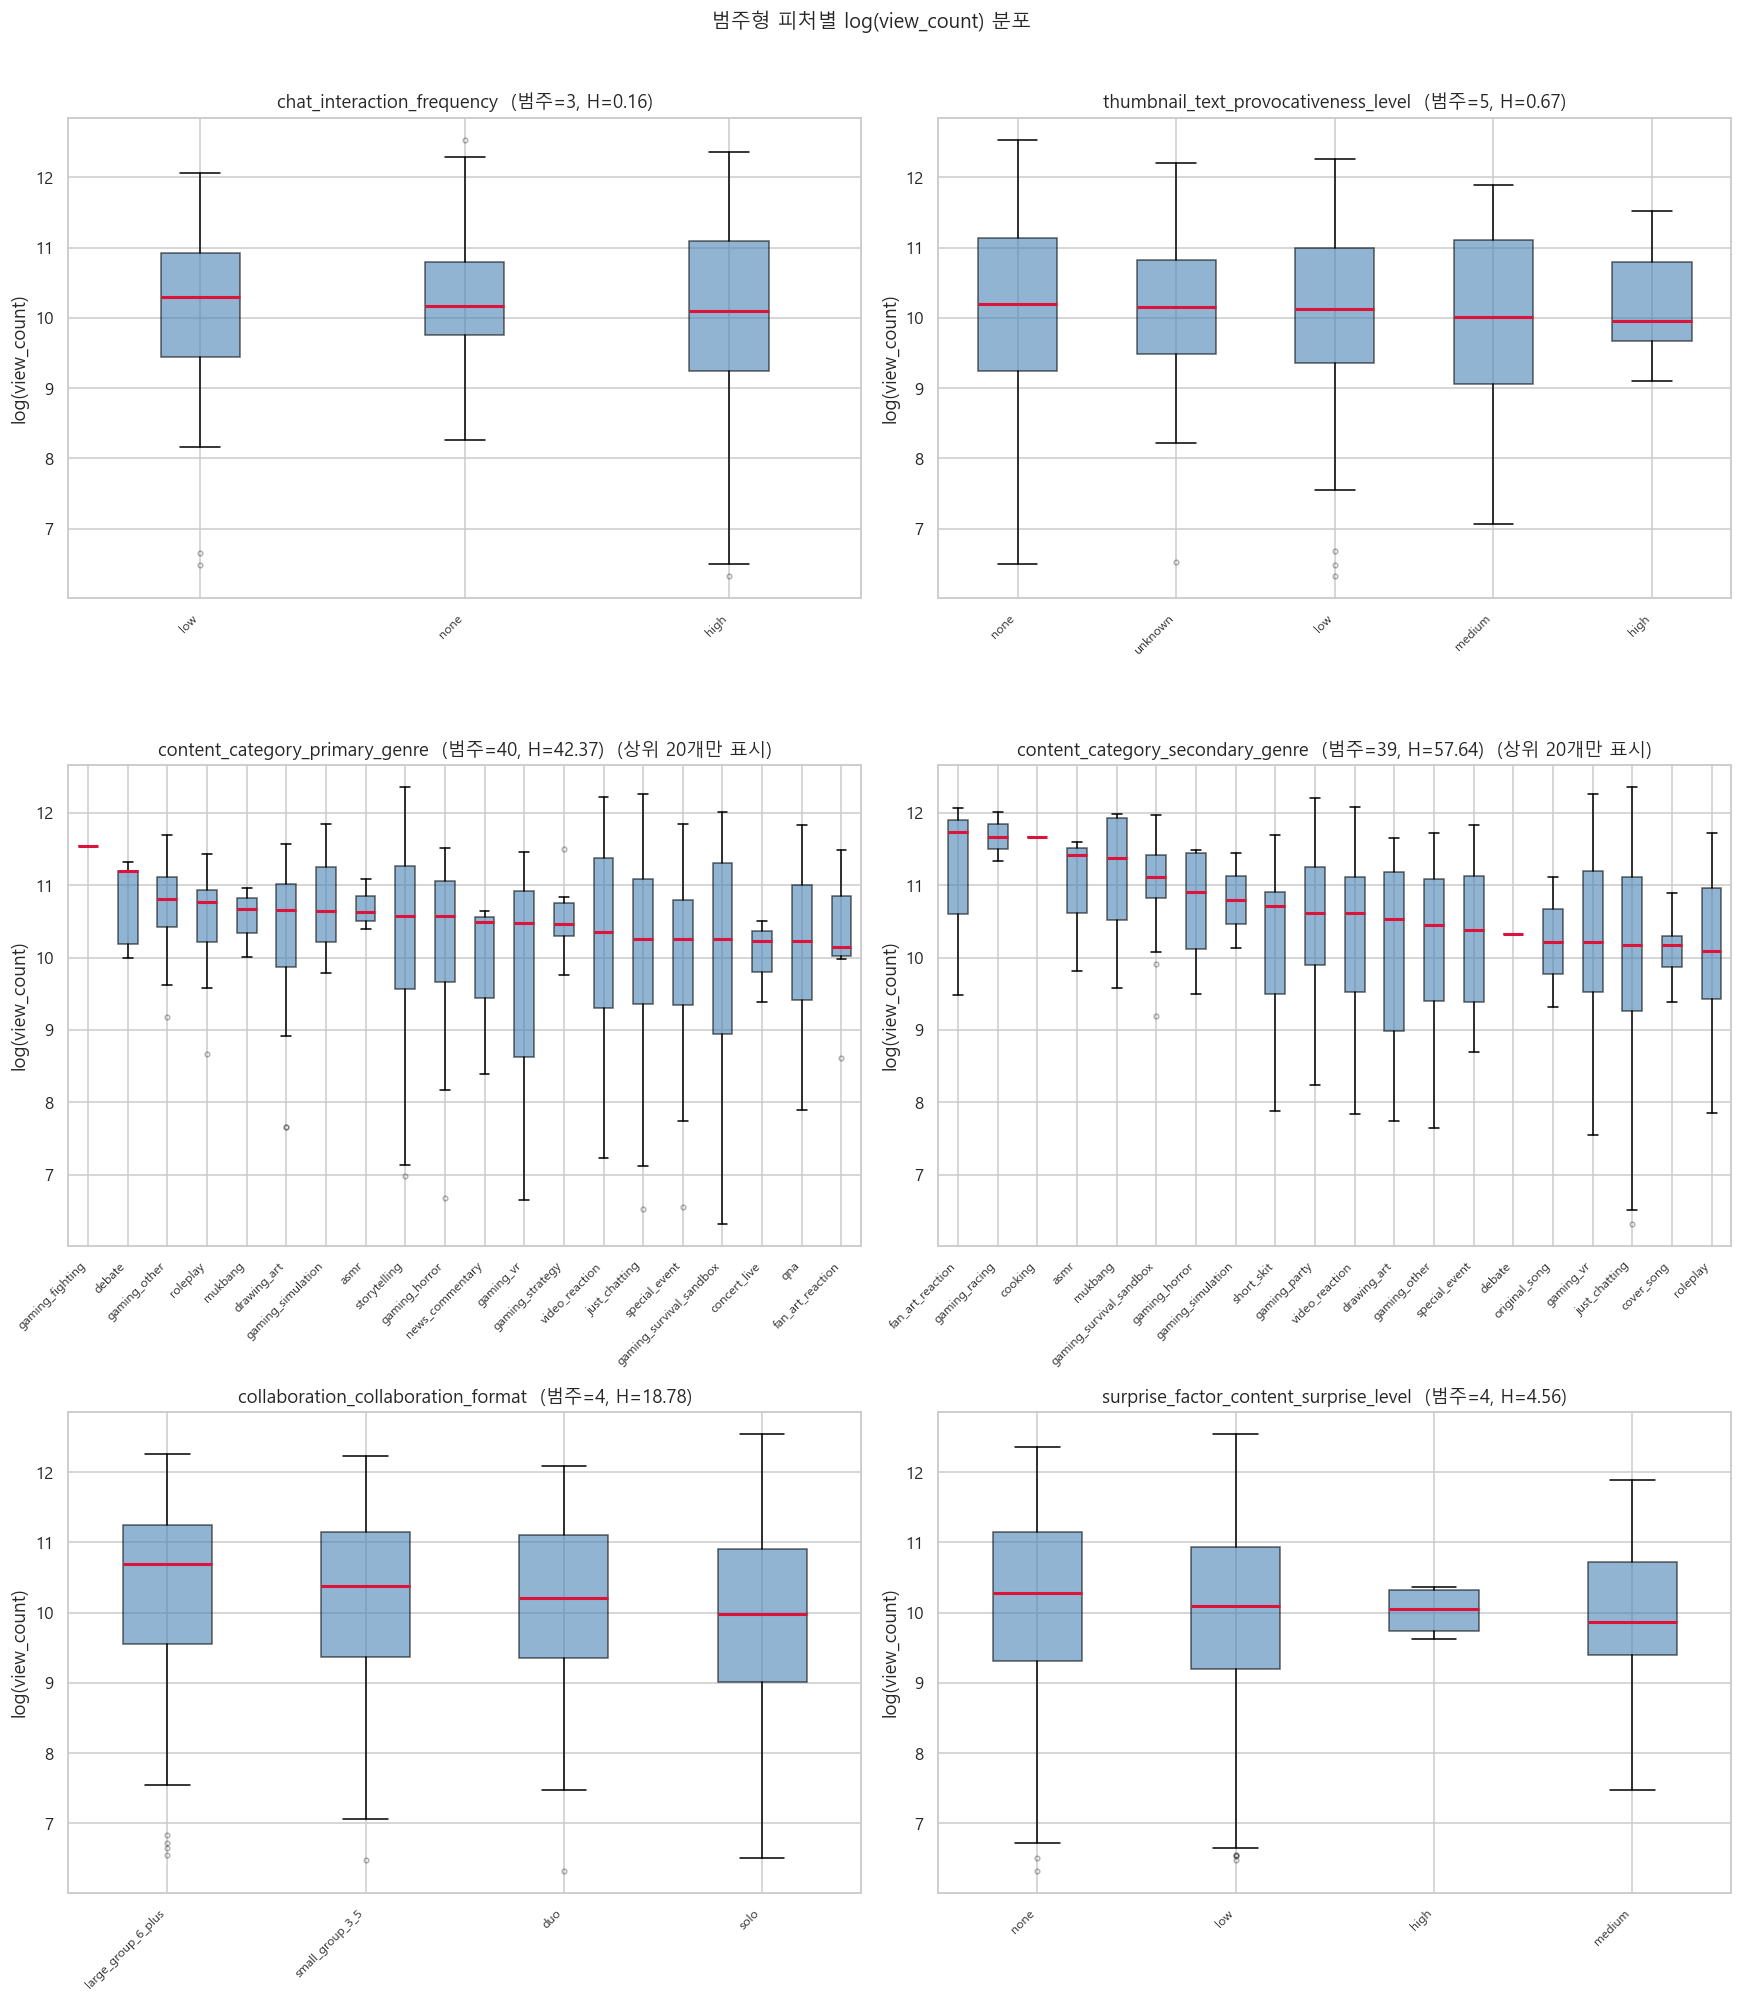

In [36]:
# 모델 선택 피처 vs view_count (수치형 Spearman / 범주형 Kruskal-Wallis)
result.run_result_eda(train, test=test)